# Multivariate Regression Models
Linear Regression, LGBM, Random Forest and XGBoost.

# 0. Imports

In [1]:
# To be able to import utils' functions
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
# Utils
from utils.data_loader_utils import load_sales_data
from utils.feature_engineering_utils import create_features

from tqdm import tqdm

import os

# Types
from typing import List, Tuple

# Data Analysis
import pandas as pd
import numpy as np

# Feature Engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Models
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.svm import SVR
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures 
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [3]:
df_sales = load_sales_data(
    sales_data_path='../data/train.csv',
    add_demand_classification=True
)

df_sales = df_sales[df_sales['date'] >= '2017-04-15']

display(df_sales)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2781702,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
2781703,2017-04-15,1,BABY CARE,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
2781704,2017-04-15,1,BEAUTY,1.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781705,2017-04-15,1,BEVERAGES,1946.000,13,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781706,2017-04-15,1,BOOKS,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,lumpy


In [4]:
# Get features
df_sales, feature_names = create_features(df_sales)

feature_names = feature_names[:3]

print(feature_names)
display(df_sales)

['onpromotion', 'month', 'dcoilwtico']


,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type,month
0,2017-04-15,1,AUTOMOTIVE,3.0,0,52.905000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
1,2017-04-16,1,AUTOMOTIVE,1.0,0,52.762500,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
2,2017-04-17,1,AUTOMOTIVE,1.0,0,52.620000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
3,2017-04-18,1,AUTOMOTIVE,3.0,0,52.460000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
4,2017-04-19,1,AUTOMOTIVE,4.0,0,50.490000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219181,2017-08-11,54,SEAFOOD,0.0,0,48.810000,El Carmen,Manabi,C,3,Traslado Primer Grito de Independencia,N/A,N/A,lumpy,8
219182,2017-08-12,54,SEAFOOD,1.0,1,48.403333,El Carmen,Manabi,C,3,N/A,N/A,N/A,lumpy,8
219183,2017-08-13,54,SEAFOOD,2.0,0,47.996667,El Carmen,Manabi,C,3,N/A,N/A,N/A,lumpy,8
219184,2017-08-14,54,SEAFOOD,0.0,0,47.590000,El Carmen,Manabi,C,3,N/A,N/A,N/A,lumpy,8


In [5]:
# Get granularity with the most sales
display(
     df_sales
    .groupby(['store_nbr', 'family'])['sales']
    .sum()
    .reset_index()
    .sort_values(by='sales', ascending=False)
    .head(n=30)
)

,store_nbr,family,sales
1464,45,GROCERY I,1.438902e+06
1530,47,GROCERY I,1.352396e+06
1422,44,BEVERAGES,1.315946e+06
1497,46,GROCERY I,1.309076e+06
1431,44,GROCERY I,1.307104e+06
1449,44,PRODUCE,1.227505e+06
1455,45,BEVERAGES,1.219718e+06
1521,47,BEVERAGES,1.160675e+06
69,3,BEVERAGES,1.128807e+06
1563,48,GROCERY I,1.086235e+06


In [123]:
# Select granularity with a lot of sales
df_subset = df_sales[(df_sales['store_nbr'] == 45) & (df_sales['family'] == 'GROCERY I')].sort_values(by='date')

display(df_subset)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type,month
180072,2017-04-15,45,GROCERY I,13064.0,106,52.905000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,4
180073,2017-04-16,45,GROCERY I,17177.0,112,52.762500,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,4
180074,2017-04-17,45,GROCERY I,10326.0,100,52.620000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,4
180075,2017-04-18,45,GROCERY I,9012.0,109,52.460000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,4
180076,2017-04-19,45,GROCERY I,9549.0,133,50.490000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180190,2017-08-11,45,GROCERY I,11088.0,40,48.810000,Quito,Pichincha,A,11,Traslado Primer Grito de Independencia,N/A,N/A,smooth,8
180191,2017-08-12,45,GROCERY I,9917.0,39,48.403333,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,8
180192,2017-08-13,45,GROCERY I,12723.0,38,47.996667,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,8
180193,2017-08-14,45,GROCERY I,9665.0,39,47.590000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth,8


# 1. Linear Regression

In [102]:
def plot_last_fold(df_sales: pd.DataFrame, fold_data: dict,
                    date_col: str = 'date'):
    """
    Plot results from the last fold of a cross-validation.
    
    Args:
        df_sales: Original dataframe with dates
        fold_data: Dictionary with last fold data.
        date_col: name of the date column. Defaults
            to 'date'.
    """
    
    train_idx = fold_data['train_idx']
    test_idx = fold_data['test_idx']
    
    # Get last 90 days of training for visualization
    train_plot_start = max(0, len(train_idx) - 90)
    train_plot_indices = train_idx[train_plot_start:]
    
    # Extract data
    dates_train = df_sales[date_col].iloc[train_plot_indices].values
    y_train = fold_data['y_train'].iloc[train_plot_start:].values \
        if isinstance(fold_data['y_train'], pd.Series) else fold_data['y_train'][train_plot_start]
    fitted = fold_data['fitted_values'].iloc[train_plot_start:].values \
        if isinstance(fold_data['fitted_values'], pd.Series) else fold_data['fitted_values'][train_plot_start:]
    
    dates_test = df_sales[date_col].iloc[test_idx].values 
    y_test = fold_data['y_test'].values if isinstance(fold_data['y_test'], pd.Series) else fold_data['y_test']
    forecast = fold_data['forecast'].values if isinstance(fold_data['forecast'], pd.Series) else fold_data['forecast']
    
    # Create plot
    plt.figure(figsize=(14, 6))
    
    # Train data
    sns.lineplot(
        x=dates_train,
        y=y_train,
        label='Train (Real)',
        alpha=0.7,
        color='blue'
    )

    # Fitted values
    sns.lineplot(
        x=dates_train,
        y=fitted,
        label='Fitted Values',
        linestyle='--',
        color='blue',
        alpha=0.5
    )
    
    # Test data
    sns.lineplot(
        x=dates_test,
        y=y_test,
        label='Test (Real)',
        alpha=0.7,
        color='green',
        linewidth=2
    )
    
    # Forecast
    sns.lineplot(
        x=dates_test,
        y=forecast,
        label='Forecast',
        linestyle='--',
        color='red',
        linewidth=2
    )
        
    plt.title("Real vs Predicted (Last Fold)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Running 5 folds with test_size=15...

Fold 1:
  Train: 2017-04-15 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.2946
  Test RMSLE: 0.4819

Fold 2:
  Train: 2017-04-15 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.3196
  Test RMSLE: 0.4545

Fold 3:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.3098
  Test RMSLE: 0.2468

Fold 4:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.2965
  Test RMSLE: 0.7544

Fold 5:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.3447
  Test RMSLE: 0.8856

Cross-Validation Results:
   Train RMSLE Mean: 0.3130
   Train RMSLE Std:  0.0183
   Train Min RMSLE:  0.2946
   Train Max RMSLE:  0.3447
   Test RMSLE Mean: 0.5646
   Test RMSLE Std:  0.2276
   Test Min RMSLE:  0.2468
   Test Max RMSLE:  0.8856


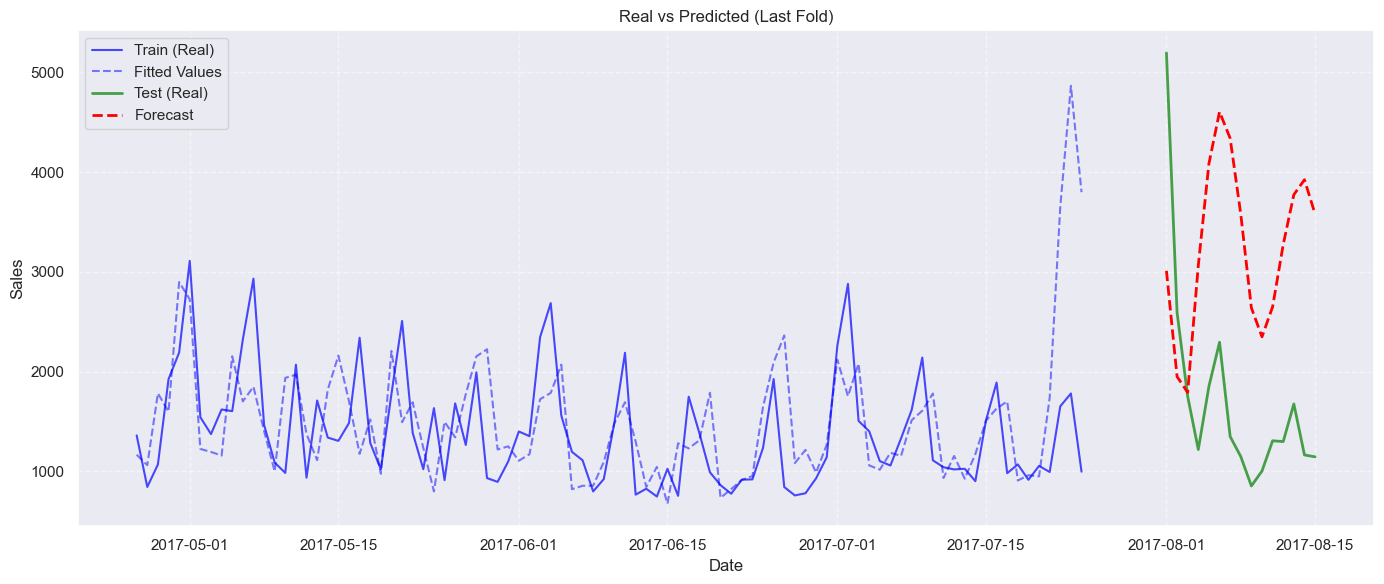

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,20,CLEANING,0.313039,0.018267,0.29456,0.344693,0.564647,0.22761,0.24679,0.885583,190219.0,123,smooth,5


In [107]:
def train_and_evaluate_linear_regression_model(df_sales: pd.DataFrame, feature_cols: List[str],
                                               n_splits: int = 5, test_size: int = 15,
                                               plot_results: bool = False, skew_threshold: int = None,
                                               verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a linear regression model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.set_index('date').sort_index().asfreq('D')
    
    # numerical_features = ['onpromotion']
    # event_features = [col for col in feature_cols if 'event' in col]
    # categorical_features = event_features + ['month']

    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'


    X = df_sales[feature_cols]
    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(X)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        # Split data
        X_train, y_train = X.iloc[train_idx][feature_cols], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx][feature_cols], y.iloc[test_idx]

        # transformer_exog = ColumnTransformer(
        #     transformers=[
        #         ('scale', MinMaxScaler(), numerical_features),
        #         # ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        #     ]
        # )

        model = ForecasterRecursive(
            estimator=LinearRegression(),
            lags=7,
            # transformer_y=MinMaxScaler(),
            # transformer_exog=transformer_exog,
            # weight_func=lambda x: np.log1p(np.linspace(0, 1, len(x)))
        )

        model.fit(
            y=y_train,
            exog=X_train
        )

        # ---- FORECAST VALUES ----
        test_forecast = model.predict(
            steps=test_size,
            exog=X_test
        )

        # ---- FITTED VALUES ----
        X_train_aux, y_train_aux = model.create_train_X_y(
            y=y_train,
            exog=X_train
        )

        fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
        fitted_values = fitted_values.reshape(-1,)

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast


        real_train_aux = y_train_aux.values.reshape(-1, 1)

        train_rmsle = root_mean_squared_log_error(real_train_aux, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales.index[train_idx]
            test_dates = df_sales.index[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if fold == tscv.get_n_splits(y):
            X_train_aux, y_train_aux = model.create_train_X_y(
                y=y_train,
                exog=X_train
            )

            fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
            fitted_values = fitted_values.reshape(-1,)
            
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train

            train_idx = train_idx[:-7]
            y_train_real = y_train_real[:-7]

            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales.reset_index(), last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })


df_metrics = train_and_evaluate_linear_regression_model(
    df_subset,
    feature_cols=['onpromotion'],
    verbose=True, 
    plot_results=True
)

display(df_metrics)

In [9]:
df_sampled = pd.read_csv('../data/experiments_results/sampled_data.csv')

df_sampled, feature_names = create_features(df_sampled)
feature_names = feature_names[:3]

display(df_sampled)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type,month
0,2017-01-15,1,AUTOMOTIVE,1.000,0,52.405000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,1
1,2017-01-16,1,AUTOMOTIVE,3.000,0,52.427500,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,1
2,2017-01-17,1,AUTOMOTIVE,2.000,0,52.450000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,1
3,2017-01-18,1,AUTOMOTIVE,3.000,0,51.120000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,1
4,2017-01-19,1,AUTOMOTIVE,2.000,0,51.390000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18952,2017-08-11,54,PRODUCE,546.250,3,48.810000,El Carmen,Manabi,C,3,Traslado Primer Grito de Independencia,N/A,N/A,smooth,8
18953,2017-08-12,54,PRODUCE,696.920,4,48.403333,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8
18954,2017-08-13,54,PRODUCE,877.304,4,47.996667,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8
18955,2017-08-14,54,PRODUCE,585.615,3,47.590000,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8


In [108]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training Linear Regression model'):
    try:
        df_metrics = train_and_evaluate_linear_regression_model(
                df_sales=df,
                feature_cols=['onpromotion']
            )

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_linear_regression = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_linear_regression.sort_values(by='test_rmsle_mean'))

Training Linear Regression model: 100%|██████████| 89/89 [00:06<00:00, 14.36it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,lumpy,5
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,intermittent,5
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,intermittent,5
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,intermittent,5
88,54,PRODUCE,0.130644,0.001375,0.128367,0.132570,0.103283,0.017454,0.080233,0.124010,142769.804030,213,smooth,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,47,HARDWARE,0.577141,0.016587,0.551865,0.595520,0.746278,0.059447,0.680348,0.858007,590.000000,188,intermittent,5
26,17,LINGERIE,0.678387,0.016294,0.649750,0.695765,0.789764,0.271503,0.374519,1.198401,1317.000000,205,erratic,5
47,31,LAWN AND GARDEN,0.921598,0.024614,0.891444,0.965730,0.812738,0.163223,0.608129,1.073596,763.000000,146,lumpy,5
36,25,FROZEN FOODS,0.909266,0.052490,0.854851,0.996950,0.882350,0.409703,0.513507,1.588620,37560.965012,213,erratic,5


In [11]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_linear_regression.to_csv('../data/experiments_results/linear_regression.csv')

# df_full_metrics_linear_regression = pd.read_csv('../data/experiments_results/linear_regression.csv')

# 2. LGBM

In [12]:
import re
import unicodedata

def sanitize_feature_name(text: str) -> str:
    """
    Sanitize a feature name by removing accents and replacing
    non-alphanumeric characters with underscores.

    Args:
        text (str): Input feature name.
    Returns:
        str: Sanitized feature name.
    """
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode()

    text = (
        text
        .replace("+", "_plus_")
        .replace("-", "_minus_")
        .replace("|", "_or_")
        .replace(":", "_")
        .replace(" ", "_")
    )

    text = re.sub(r"[^0-9a-zA-Z_]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")

Running 3 folds with test_size=15...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 63
[LightGBM] [Info] Number of data points in the train set: 71, number of used features: 7
[LightGBM] [Info] Start training from score 3.661972
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

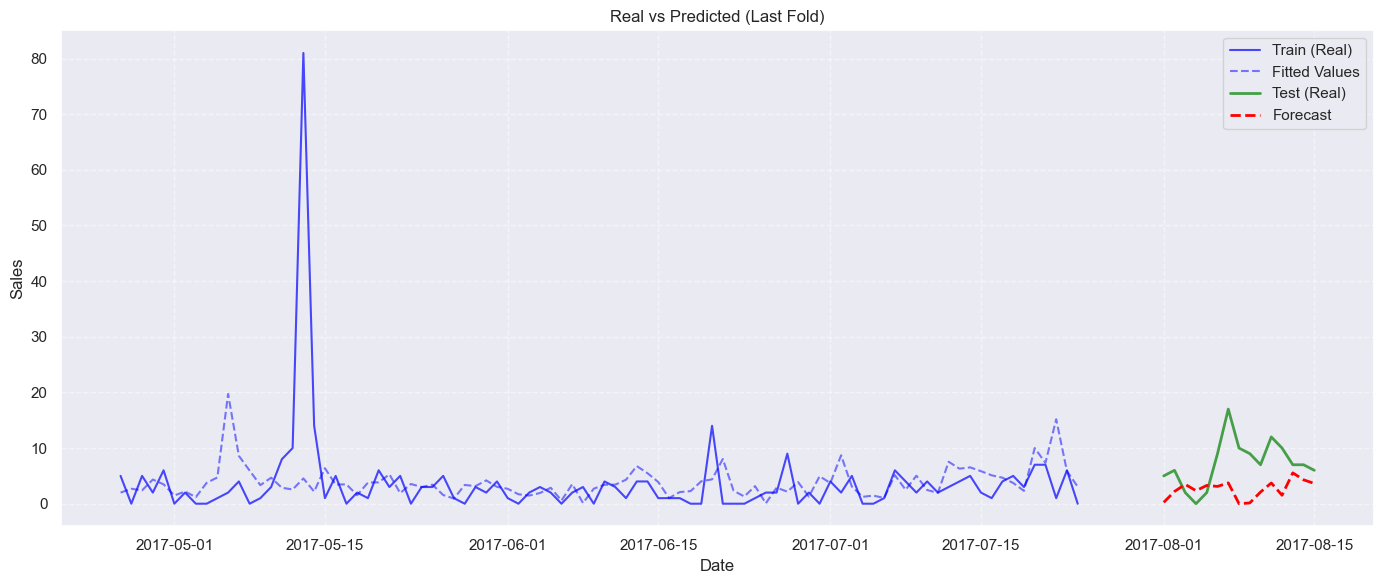

Cross-Validation Results:
   Train RMSLE Mean: 0.9301
   Train RMSLE Std:  0.0723
   Train Min RMSLE:  0.8471
   Train Max RMSLE:  1.0234
   Test RMSLE Mean: 1.1176
   Test RMSLE Std:  0.0742
   Test Min RMSLE:  1.0485
   Test Max RMSLE:  1.2206


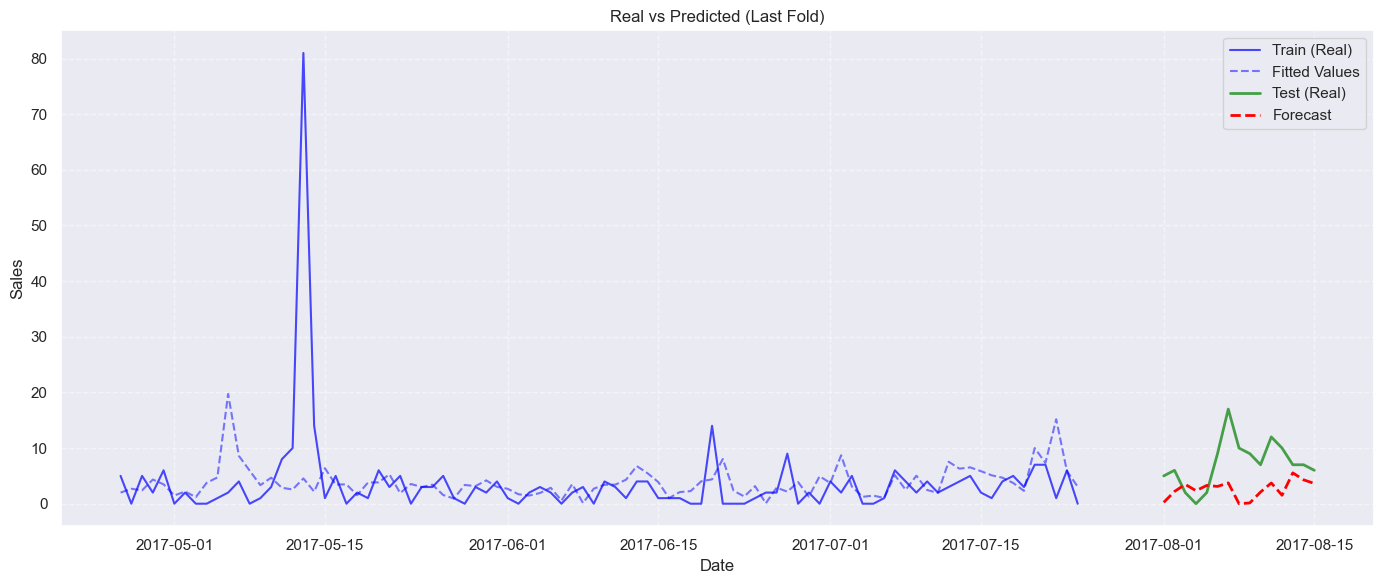

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,31,LAWN AND GARDEN,0.930125,0.072316,0.847107,1.023358,1.117597,0.074246,1.04849,1.220612,507.0,98,lumpy,3


In [122]:
from operator import le


def train_and_evaluate_lgbm_model(df_sales: pd.DataFrame, feature_cols: List[str],
                                               n_splits: int = 3, test_size: int = 15,
                                               plot_results: bool = False, skew_threshold: int = None,
                                               verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a LGBM model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.copy() 
    df_sales = df_sales.set_index('date').sort_index().asfreq('D')

    store_nbr = df_sales['store_nbr'].iloc[0]
    family = df_sales['family'].iloc[0]
    demand_type = df_sales['demand_type'].iloc[0]
    
    if len(df_sales) > 0:
        numerical_features = ['onpromotion']
        # event_features = [col for col in feature_cols if 'event' in col]
        # categorical_features = event_features + ['month']

        target_column = 'sales'
        non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

        # Apply log transformation if needed
        if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
            df_sales['sales_log'] = np.log1p(df_sales['sales'])
            target_column = 'sales_log'

        X = df_sales[feature_cols]
        y = df_sales[target_column]

        # Time Series Cross-Validation
        tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
        
        train_cv_metrics = []
        test_cv_metrics = []
        last_fold_data = None

        if verbose:
            print(f"Running {tscv.get_n_splits(X)} folds with test_size={test_size}...\n")

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
            # Split data
            X_train, y_train = X.iloc[train_idx][feature_cols], y.iloc[train_idx]
            X_test, y_test = X.iloc[test_idx][feature_cols], y.iloc[test_idx]

            model = ForecasterRecursive(
                estimator=LGBMRegressor(
                    random_state=42,
                    verbosity=1 if verbose else -1
                ),
                lags=7
            )

            model.fit(
                y=y_train,
                # exog=X_train
            )

            # ---- FORECAST VALUES ----
            test_forecast = model.predict(
                steps=test_size,
                # exog=X_test
            )

            # ---- FITTED VALUES ----
            X_train_aux, y_train_aux = model.create_train_X_y(
                y=y_train,
                # exog=X_train
            )

            fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
            fitted_values = fitted_values.reshape(-1,)

            # Remove negative values, if any
            test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
            fitted_values = [val if val >= 0 else 0 for val in fitted_values]

            # Calculate metrics
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)

                y_test_real = np.expm1(y_test)
                forecast_real = np.expm1(test_forecast)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train

                y_test_real = y_test
                forecast_real = test_forecast

            train_rmsle = root_mean_squared_log_error(y_train_aux, fitted_values_real)
            test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

            train_cv_metrics.append(train_rmsle)
            test_cv_metrics.append(test_rmsle)

            if verbose:
                train_dates = df_sales.index[train_idx]
                test_dates = df_sales.index[test_idx]
                print(f"Fold {fold}:")
                print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
                print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

                print(f"  Train RMSLE: {train_rmsle:.4f}")
                print(f"  Test RMSLE: {test_rmsle:.4f}\n")

            # Store last fold data for plotting
            if plot_last_fold and fold == tscv.get_n_splits(y):
                X_train_aux, y_train_aux = model.create_train_X_y(
                    y=y_train,
                    # exog=X_train
                )

                fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
                fitted_values = fitted_values.reshape(-1,)
                
                if 'log' in target_column:
                    fitted_values_real = np.expm1(fitted_values)
                    y_train_real = np.expm1(y_train)
                else:
                    fitted_values_real = fitted_values
                    y_train_real = y_train


                train_idx = train_idx[:-7]
                y_train_real = y_train_real[:-7]
                    
                last_fold_data = {
                    'train_idx': train_idx,
                    'test_idx': test_idx,
                    'y_train': y_train_real,
                    'fitted_values': fitted_values_real,
                    'y_test': y_test_real,
                    'forecast': forecast_real,
                }

                if plot_results:
                    plot_last_fold(df_sales.reset_index(), last_fold_data)

        # Print summary
        if len(test_cv_metrics) > 0:
            mean_train_rmsle = np.mean(train_cv_metrics)
            std_train_rmsle = np.std(train_cv_metrics)

            mean_test_rmsle = np.mean(test_cv_metrics)
            std_test_rmsle = np.std(test_cv_metrics)
            
            if verbose:
                print("=" * 60)
                print("Cross-Validation Results:")
                print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
                print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
                print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
                print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
                print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
                print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
                print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
                print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
                print("=" * 60)

            # Plot last fold if requested
            if plot_results and last_fold_data is not None:
                plot_last_fold(df_sales.reset_index(), last_fold_data)

            return pd.DataFrame({
                'store_nbr': [store_nbr],
                'family': [family],
                'train_rmsle_mean': [mean_train_rmsle],
                'train_rmsle_std': [std_train_rmsle],
                'train_rmsle_min': [min(train_cv_metrics)],
                'train_rmsle_max': [max(train_cv_metrics)],
                'test_rmsle_mean': [mean_test_rmsle],
                'test_rmsle_std': [std_test_rmsle],
                'test_rmsle_min': [min(test_cv_metrics)],
                'test_rmsle_max': [max(test_cv_metrics)],
                'total_sales': [df_sales['sales'].sum()],
                'sales_count': [non_zero_sales_count],
                'demand_type': [demand_type],
                'n_folds': [len(test_cv_metrics)]
            })
        else:
            if verbose:
                print("No successful folds completed")
            
            return pd.DataFrame({
                'store_nbr': [store_nbr],
                'family': [family],
                'train_rmsle_mean': [np.nan],
                'train_rmsle_std': [np.nan],
                'train_rmsle_min': [np.nan],
                'train_rmsle_max': [np.nan],
                'test_rmsle_mean': [np.nan],
                'test_rmsle_std': [np.nan],
                'test_rmsle_min': [np.nan],
                'test_rmsle_max': [np.nan],
                'total_sales': [df_sales['sales'].sum()],
                'sales_count': [non_zero_sales_count],
                'demand_type': [demand_type],
                'n_folds': [0]
            })
    else:
        return pd.DataFrame({
            'store_nbr': [store_nbr],
            'family': [family],
            'train_rmsle_mean': [0],
            'train_rmsle_std': [0],
            'train_rmsle_min': [0],
            'train_rmsle_max': [0],
            'test_rmsle_mean': [0],
            'test_rmsle_std': [0],
            'test_rmsle_min': [0],
            'test_rmsle_max': [0],
            'total_sales': [0],
            'sales_count': [0],
            'demand_type': [demand_type],
            'n_folds': [0]
        })

# Uso da função
df_metrics = train_and_evaluate_lgbm_model(
    df_sales[(df_sales['store_nbr'] == 31) & (df_sales['family'] == 'LAWN AND GARDEN')],
    feature_cols=['onpromotion'],
    verbose=True, 
    plot_results=True
)

display(df_metrics)

In [118]:
display(df_full_metrics_lgbm[df_full_metrics_lgbm['train_rmsle_mean'] < df_full_metrics_lgbm['test_rmsle_mean']].sort_values(by='test_rmsle_mean', ascending=False))

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
36,25,FROZEN FOODS,0.671104,0.025459,0.636079,0.695839,1.887686,0.059765,1.808156,1.952230,3.756097e+04,213,erratic,3
78,47,SCHOOL AND OFFICE SUPPLIES,0.525535,0.117336,0.437065,0.691349,1.872622,1.287469,0.786450,3.681227,9.710000e+03,203,lumpy,3
85,52,SCHOOL AND OFFICE SUPPLIES,1.126602,0.046643,1.068481,1.182677,1.465293,0.325872,1.190671,1.923113,2.232000e+03,113,erratic,3
47,31,LAWN AND GARDEN,0.909968,0.026436,0.884237,0.946322,1.112127,0.179178,0.865472,1.285735,7.630000e+02,146,lumpy,3
26,17,LINGERIE,0.481130,0.019712,0.453255,0.495327,0.847292,0.242096,0.519778,1.097458,1.317000e+03,205,erratic,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,44,GROCERY I,0.084674,0.004739,0.078514,0.090041,0.141238,0.047818,0.102046,0.208561,2.294273e+06,213,smooth,3
40,27,MEATS,0.066969,0.002614,0.063683,0.070078,0.138344,0.006120,0.130022,0.144563,6.522187e+04,213,smooth,3
18,12,PRODUCE,0.080547,0.004770,0.075622,0.087001,0.133917,0.034423,0.085937,0.165037,7.736589e+04,213,smooth,3
88,54,PRODUCE,0.063817,0.001978,0.061255,0.066071,0.116919,0.018437,0.094563,0.139717,1.427698e+05,213,smooth,3


In [116]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training LGBM model'):
    try:
        df_metrics = train_and_evaluate_lgbm_model(
            df_sales=df,
            feature_cols=['onpromotion'],
            )

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_lgbm = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_lgbm.sort_values(by='test_rmsle_mean'))

Training LGBM model:   0%|          | 0/89 [00:00<?, ?it/s]

Training LGBM model: 100%|██████████| 89/89 [00:07<00:00, 11.31it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,lumpy,3
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
74,45,PRODUCE,0.167279,0.010305,0.153826,0.178859,0.115064,0.021379,0.097804,0.145192,1.452935e+06,213,erratic,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,17,LINGERIE,0.481130,0.019712,0.453255,0.495327,0.847292,0.242096,0.519778,1.097458,1.317000e+03,205,erratic,3
47,31,LAWN AND GARDEN,0.909968,0.026436,0.884237,0.946322,1.112127,0.179178,0.865472,1.285735,7.630000e+02,146,lumpy,3
85,52,SCHOOL AND OFFICE SUPPLIES,1.126602,0.046643,1.068481,1.182677,1.465293,0.325872,1.190671,1.923113,2.232000e+03,113,erratic,3
78,47,SCHOOL AND OFFICE SUPPLIES,0.525535,0.117336,0.437065,0.691349,1.872622,1.287469,0.786450,3.681227,9.710000e+03,203,lumpy,3


In [117]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_lgbm.to_csv('../data/experiments_results/lgbm.csv')

# df_full_metrics_lgbm = pd.read_csv('../data/experiments_results/lgbm.csv')

# 3. RandomForestRegressor

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


Running 3 folds with test_size=15...



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_job

Fold 1:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.0702
  Test RMSLE: 0.1582



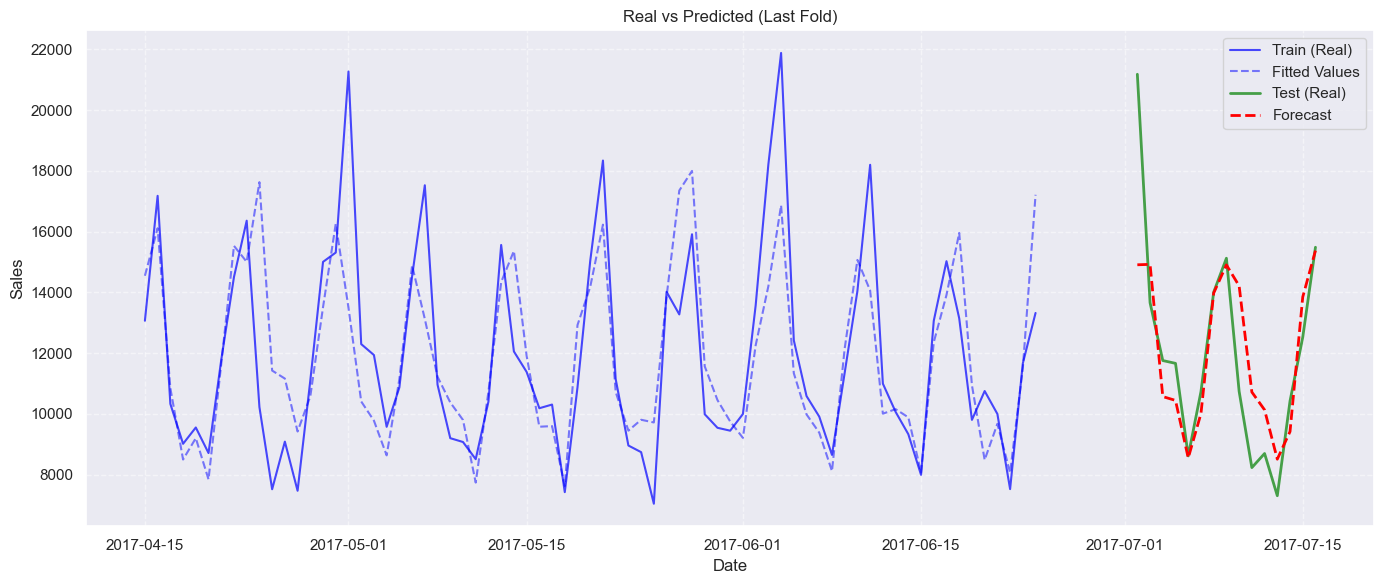

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_

Fold 2:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.0643
  Test RMSLE: 0.1671



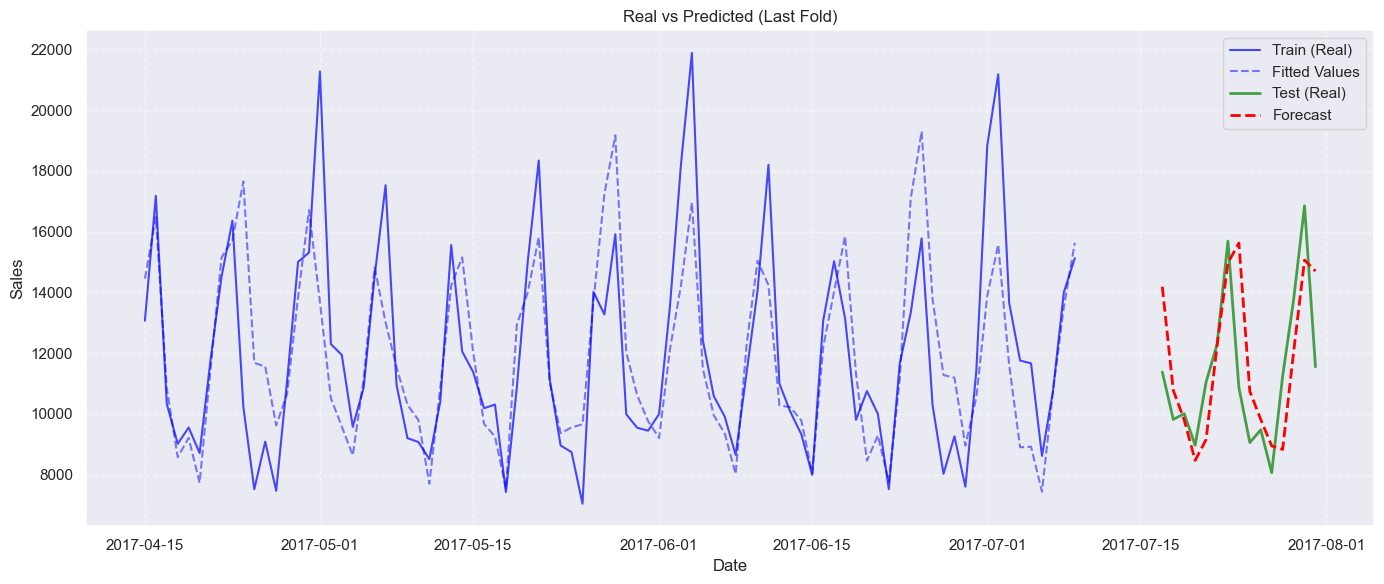

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_

Fold 3:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.0604
  Test RMSLE: 0.1741



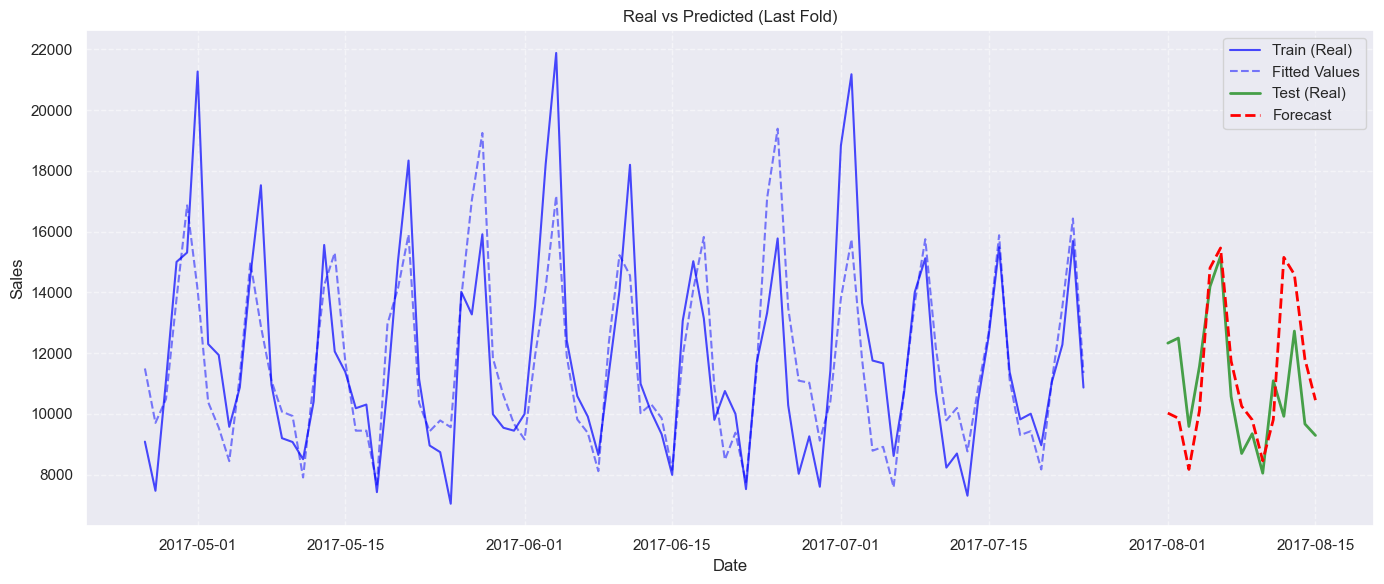

Cross-Validation Results:
   Train RMSLE Mean: 0.0650
   Train RMSLE Std:  0.0040
   Train Min RMSLE:  0.0604
   Train Max RMSLE:  0.0702
   Test RMSLE Mean: 0.1664
   Test RMSLE Std:  0.0065
   Test Min RMSLE:  0.1582
   Test Max RMSLE:  0.1741


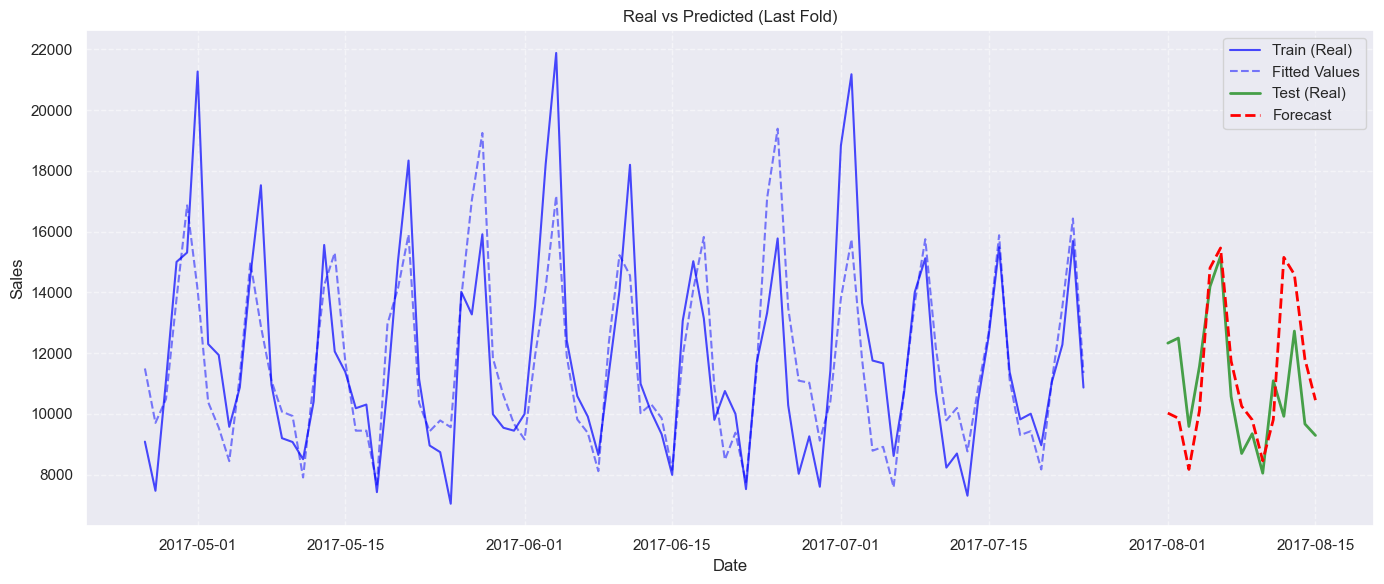

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,45,GROCERY I,0.064956,0.004004,0.06042,0.070159,0.166446,0.006514,0.158153,0.174067,1438902.0,123,smooth,3


In [16]:
def train_and_evaluate_random_forest_model(df_sales: pd.DataFrame, feature_cols: List[str],
                                               n_splits: int = 3, test_size: int = 15,
                                               plot_results: bool = False, skew_threshold: int = None,
                                               verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a random forest regressor model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.copy()  # Evitar modificar o DataFrame original
    df_sales = df_sales.set_index('date').sort_index().asfreq('D')

    # numerical_features = ['onpromotion']
    # event_features = [col for col in feature_cols if 'event' in col]
    # categorical_features = event_features + ['month']

    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    X = df_sales[feature_cols]
    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(X)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        # Split data
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]


        model = ForecasterRecursive(
            estimator=RandomForestRegressor(
                n_jobs=-1,
                random_state=42,
                # criterion='poisson',
                # min_impurity_decrease=0.1,
                verbose=int(verbose)
            ),
            lags=7,
            # window_features=window_features
        )

        model.fit(
            y=y_train,
            exog=X_train
        )

        # ---- FORECAST VALUES ----
        test_forecast = model.predict(
            steps=test_size,
            exog=X_test
        )

        # ---- FITTED VALUES ----
        X_train_aux, y_train_aux = model.create_train_X_y(
            y=y_train,
            exog=X_train
        )

        fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
        fitted_values = fitted_values.reshape(-1,)

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_aux, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales.index[train_idx]
            test_dates = df_sales.index[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if plot_results or fold == tscv.get_n_splits(y):
            X_train_aux, y_train_aux = model.create_train_X_y(
                y=y_train,
                exog=X_train
            )

            fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
            fitted_values = fitted_values.reshape(-1,)
            
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train

            train_idx = train_idx[:-7]
            y_train_real = y_train_real[:-7]
                
            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

            if plot_results:
                plot_last_fold(df_sales.reset_index(), last_fold_data)

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales.reset_index(), last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })


# Uso da função
df_metrics = train_and_evaluate_random_forest_model(
    df_subset,
    feature_cols=['onpromotion'],
    verbose=True, 
    plot_results=True
)

display(df_metrics)

In [17]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training RandomForestRegressor model'):
    try:
        df_metrics = train_and_evaluate_random_forest_model(
            df_sales=df,
            feature_cols=['onpromotion'],
            # skew_threshold=2.0
            )

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_random_forest = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_random_forest.sort_values(by='test_rmsle_mean'))

Training RandomForestRegressor model: 100%|██████████| 89/89 [03:03<00:00,  2.07s/it]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,lumpy,3
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,intermittent,3
74,45,PRODUCE,0.146853,0.003974,0.142849,0.152271,0.092380,0.017238,0.078790,0.116703,1.452935e+06,213,erratic,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,17,LINGERIE,0.355261,0.008693,0.346561,0.367134,0.790832,0.189729,0.539671,0.998168,1.317000e+03,205,erratic,3
75,47,HARDWARE,0.302908,0.004470,0.298483,0.309029,0.799078,0.074341,0.738646,0.903798,5.900000e+02,188,intermittent,3
36,25,FROZEN FOODS,0.250344,0.006886,0.244769,0.260047,0.826424,0.506456,0.419054,1.540289,3.756097e+04,213,erratic,3
78,47,SCHOOL AND OFFICE SUPPLIES,0.287544,0.007296,0.278237,0.296055,0.872627,0.204757,0.595439,1.083772,9.710000e+03,203,lumpy,3


In [18]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_random_forest.to_csv('../data/experiments_results/random_forest.csv')

# df_full_metrics_random_forest = pd.read_csv('../data/experiments_results/random_forest.csv')

# 4. XGBoost

Running 3 folds with test_size=15...

Fold 1:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.0000
  Test RMSLE: 0.1495



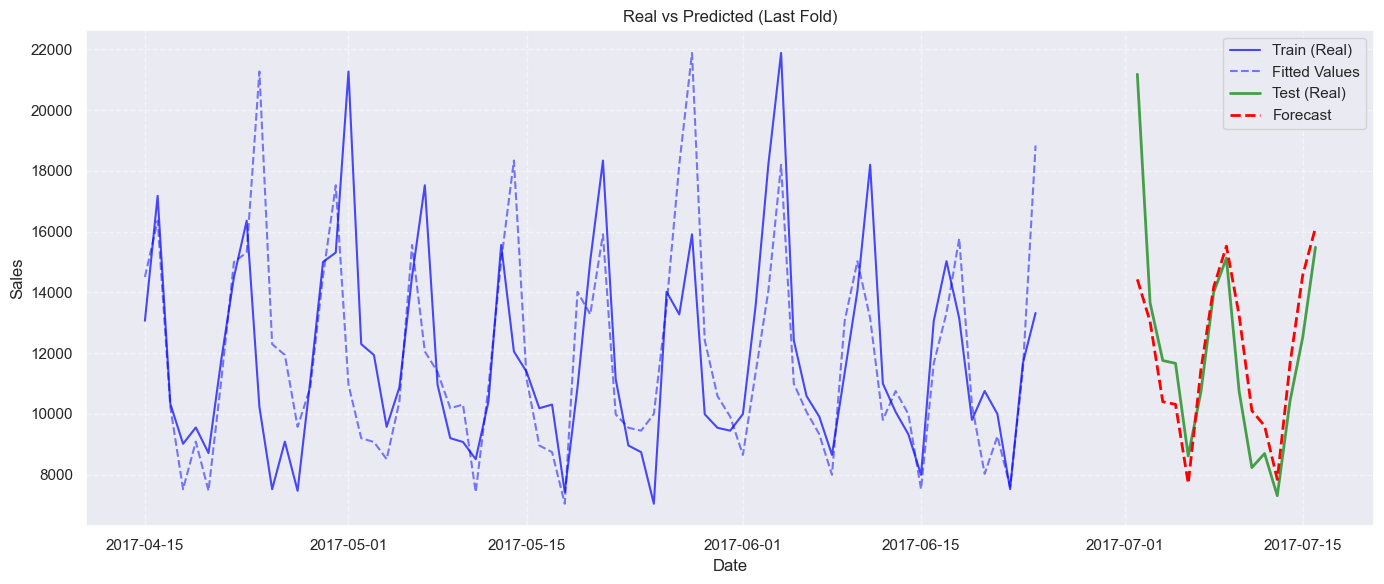

Fold 2:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.0000
  Test RMSLE: 0.2796



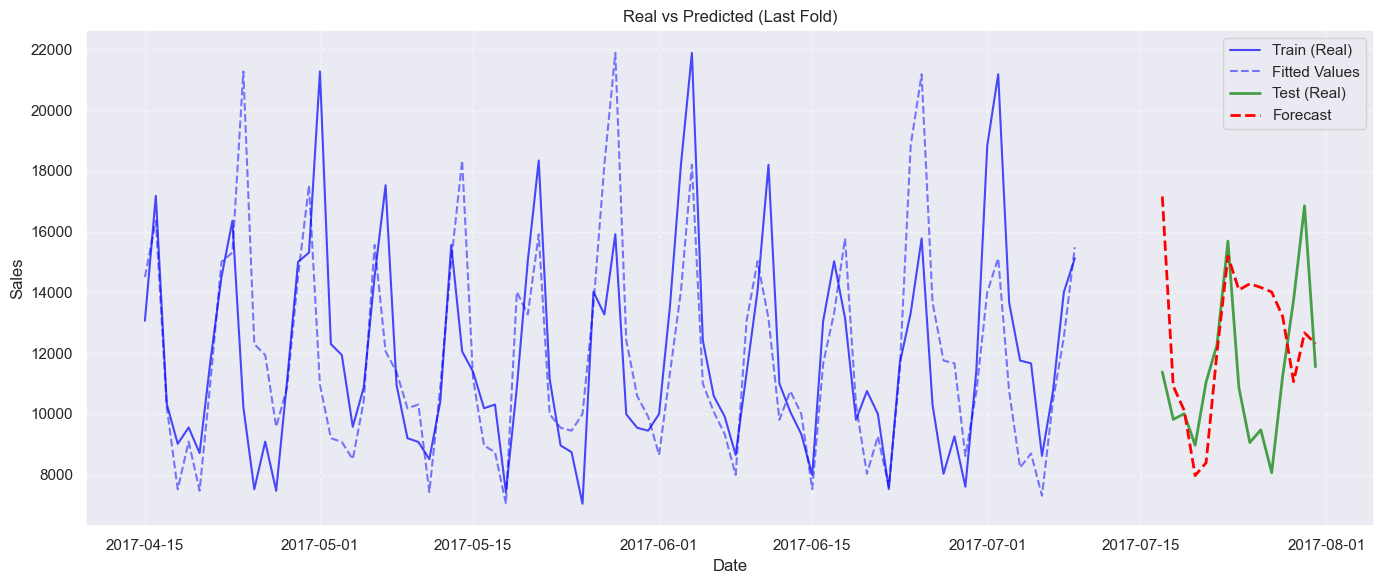

Fold 3:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.0000
  Test RMSLE: 0.1977



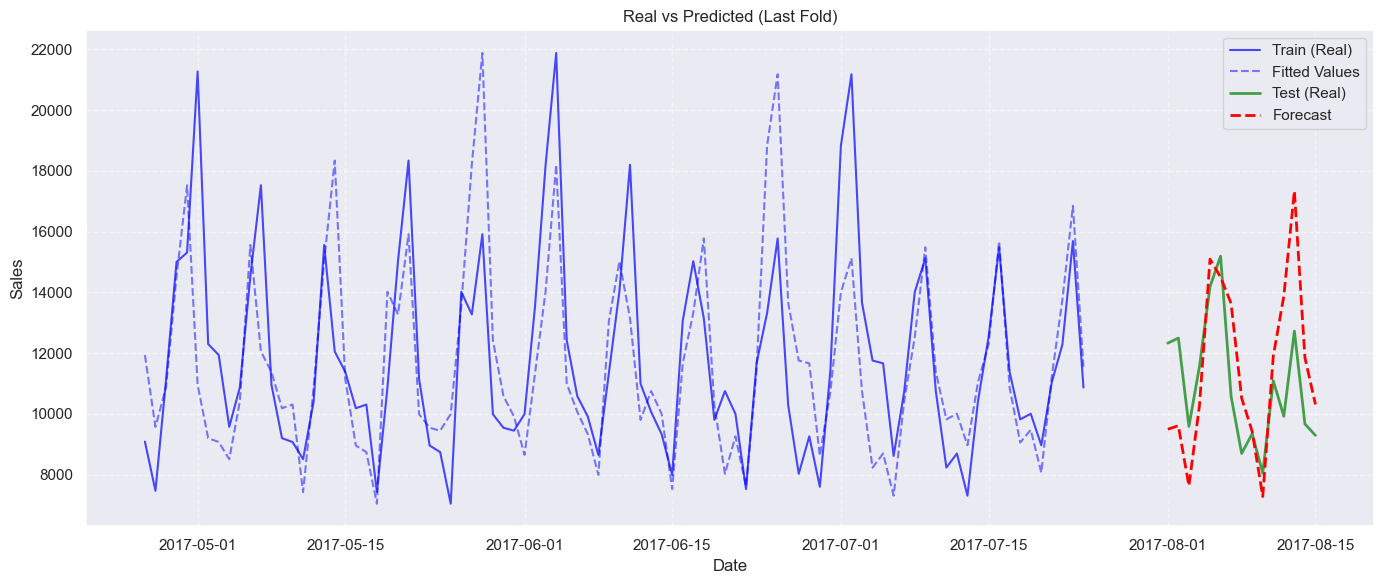

Cross-Validation Results:
   Train RMSLE Mean: 0.0000
   Train RMSLE Std:  0.0000
   Train Min RMSLE:  0.0000
   Train Max RMSLE:  0.0000
   Test RMSLE Mean: 0.2089
   Test RMSLE Std:  0.0537
   Test Min RMSLE:  0.1495
   Test Max RMSLE:  0.2796


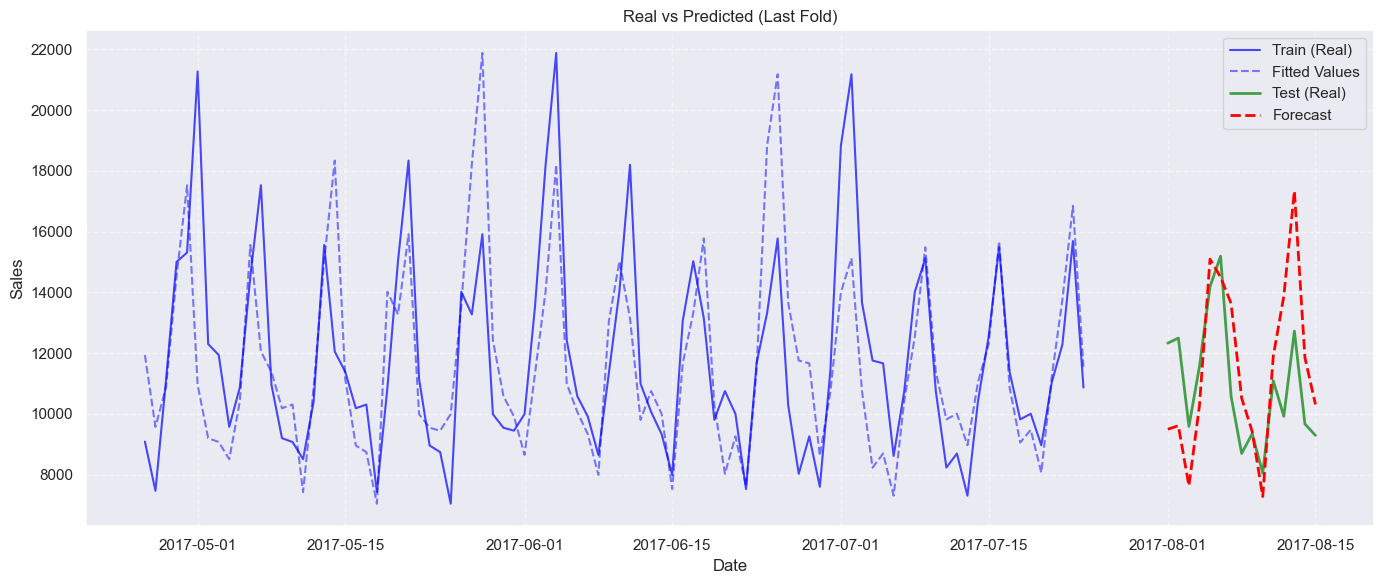

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,45,GROCERY I,3.871882e-07,5.610750e-08,3.106936e-07,4.436978e-07,0.208915,0.053676,0.149522,0.279552,1438902.0,123,smooth,3


In [19]:
def train_and_evaluate_xgboost_model(df_sales: pd.DataFrame, feature_cols: List[str],
                                               n_splits: int = 3, test_size: int = 15,
                                               plot_results: bool = False, skew_threshold: int = None,
                                               verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a random forest regressor model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.copy()  # Evitar modificar o DataFrame original
    df_sales = df_sales.set_index('date').sort_index().asfreq('D')
    
    numerical_features = ['onpromotion']
    # event_features = [col for col in feature_cols if 'event' in col]
    # categorical_features = event_features + ['month']

    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    X = df_sales[feature_cols]
    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(X)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        # Split data
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        # transformer_exog = ColumnTransformer(
        #     transformers=[
        #         (
        #             "onehot",
        #             OneHotEncoder(
        #                 handle_unknown="ignore",
        #                 sparse_output=False
        #             ),
        #             categorical_features
        #         )
        #     ],
        # )

        model = ForecasterRecursive(
            estimator=XGBRegressor(
                # n_estimators=100,
                # max_depth=5,
                # learning_rate=0.1,
                # min_child_weight=5,
                # subsample=0.8,
                # colsample_bytree=0.8,
                # reg_alpha=0.1,
                # reg_lambda=1,
                # gamma=0,
                random_state=42,
                # objective='count:poisson',
                verbosity=int(verbose)
            ),
            lags=7,
            # transformer_exog=transformer_exog
        )

        model.fit(
            y=y_train,
            exog=X_train
        )

        # ---- FORECAST VALUES ----
        test_forecast = model.predict(
            steps=test_size,
            exog=X_test
        )

        # ---- FITTED VALUES ----
        X_train_aux, y_train_aux = model.create_train_X_y(
            y=y_train,
            exog=X_train
        )

        fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
        fitted_values = fitted_values.reshape(-1,)

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_aux, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales.index[train_idx]
            test_dates = df_sales.index[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if plot_results or fold == tscv.get_n_splits(y):
            X_train_aux, y_train_aux = model.create_train_X_y(
                y=y_train,
                exog=X_train
            )

            fitted_values = model.estimator.predict(X_train_aux).reshape(-1, 1)
            fitted_values = fitted_values.reshape(-1,)
            
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train


            train_idx = train_idx[:-7]
            y_train_real = y_train_real[:-7]


            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

            if plot_results:
                plot_last_fold(df_sales.reset_index(), last_fold_data)

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales.reset_index(), last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })


# Uso da função
df_metrics = train_and_evaluate_xgboost_model(
    df_subset,
    feature_cols=['onpromotion'],
    verbose=True, 
    plot_results=True
)

display(df_metrics)

In [20]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training XGBoost model'):
    try:
        df_metrics = train_and_evaluate_xgboost_model(
            df_sales=df,
            feature_cols=['onpromotion'],
            # skew_threshold=2.0
            )

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_xgboost = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_xgboost.sort_values(by='test_rmsle_mean'))

Training XGBoost model: 100%|██████████| 89/89 [00:20<00:00,  4.38it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,3
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,3
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,lumpy,3
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,3
18,12,PRODUCE,0.000018,0.000002,0.000016,0.000020,0.107151,0.026806,0.077198,0.142250,77365.88906,213,smooth,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,47,HARDWARE,0.001476,0.000668,0.000547,0.002093,0.822083,0.056215,0.753683,0.891373,590.00000,188,intermittent,3
78,47,SCHOOL AND OFFICE SUPPLIES,0.000970,0.000650,0.000409,0.001882,0.852662,0.156204,0.647778,1.026633,9710.00000,203,lumpy,3
85,52,SCHOOL AND OFFICE SUPPLIES,0.779631,0.027215,0.747030,0.813649,0.861422,0.101097,0.719529,0.947557,2232.00000,113,erratic,3
26,17,LINGERIE,0.000477,0.000064,0.000401,0.000557,0.928968,0.230048,0.611501,1.149296,1317.00000,205,erratic,3


In [21]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_xgboost.to_csv('../data/experiments_results/xgboost.csv')

# df_full_metrics_xgboost = pd.read_csv('../data/experiments_results/xgboost.csv')

# 5. Results Analysis

In [ ]:
df_full_metrics_linear_regression = pd.read_csv('../data/experiments_results/linear_regression.csv')
df_full_metrics_linear_regression['Model'] = 'Linear Regression'

df_full_metrics_lgbm = pd.read_csv('../data/experiments_results/lgbm.csv')
df_full_metrics_lgbm['Model'] = 'LGBM'

df_full_metrics_random_forest = pd.read_csv('../data/experiments_results/random_forest.csv')
df_full_metrics_random_forest['Model'] = 'Random Forest'

df_full_metrics_xgboost = pd.read_csv('../data/experiments_results/xgboost.csv')
df_full_metrics_xgboost['Model'] = 'XGBoost'

df_full_metrics_baseline = pd.read_csv('../data/experiments_results/baseline.csv')
df_full_metrics_baseline['Model'] = 'Baseline'

df_metrics = pd.concat([df_full_metrics_linear_regression, df_full_metrics_lgbm,\
                        df_full_metrics_random_forest, df_full_metrics_xgboost,\
                        df_full_metrics_baseline], ignore_index=True)

df_metrics.drop(df_metrics.columns[0], axis=1, inplace=True)

display(df_metrics)

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds,Model
0,1,AUTOMOTIVE,0.577665,0.004880,0.572270,0.584090,0.585346,0.049094,0.522314,0.642072,883.000000,205,erratic,3,Linear Regression
1,2,GROCERY II,0.345350,0.001440,0.344190,0.347379,0.530268,0.184936,0.368693,0.789163,7599.000000,213,smooth,3,Linear Regression
2,2,HOME AND KITCHEN I,0.579817,0.016067,0.560225,0.599579,0.480974,0.132531,0.324472,0.648540,4914.000000,213,erratic,3,Linear Regression
3,3,BREAD/BAKERY,0.141832,0.001712,0.139432,0.143309,0.141358,0.024269,0.107365,0.162452,291721.699100,213,smooth,3,Linear Regression
4,3,HARDWARE,0.531839,0.007743,0.521139,0.539207,0.618006,0.009830,0.605194,0.629084,716.000000,203,smooth,3,Linear Regression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,52,CELEBRATION,1.828521,0.132603,1.702164,2.079323,0.576839,0.151596,0.361503,0.775478,1343.000000,117,smooth,5,Baseline
441,52,SCHOOL AND OFFICE SUPPLIES,1.703618,0.158998,1.482516,1.888961,0.788471,0.225583,0.460817,1.122046,2232.000000,113,erratic,5,Baseline
442,53,FROZEN FOODS,0.706472,0.201461,0.463775,0.922236,0.699821,0.213371,0.450498,1.010648,32478.255006,213,erratic,5,Baseline
443,54,HARDWARE,0.680528,0.086409,0.571338,0.836515,0.607735,0.110687,0.506203,0.768020,169.000000,104,intermittent,5,Baseline


## 5. 1. All Data

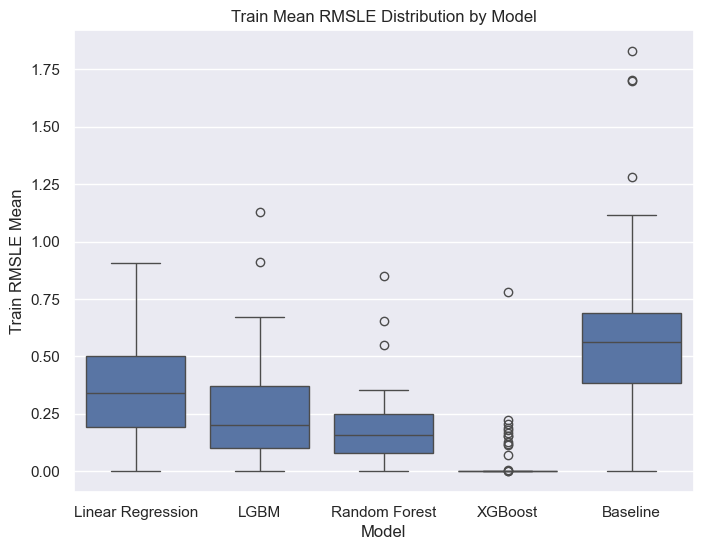

Linear Regression Mean: 0.3560
LGBM Mean: 0.2478
Random Forest Mean: 0.1796
XGBoost Mean: 0.0281
Baseline Mean: 0.5685


In [55]:
# Train set mean

plt.rcParams['figure.figsize'] = (8, 6)

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

linear_regression_train_mean = df_full_metrics_linear_regression['train_rmsle_mean'].mean()
lgbm_train_mean = df_full_metrics_lgbm['train_rmsle_mean'].mean()
random_forest_train_mean = df_full_metrics_random_forest['train_rmsle_mean'].mean()
xgboost_train_mean = df_full_metrics_xgboost['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline['train_rmsle_mean'].mean()

print(f"Linear Regression Mean: {linear_regression_train_mean:.4f}")
print(f"LGBM Mean: {lgbm_train_mean:.4f}")
print(f"Random Forest Mean: {random_forest_train_mean:.4f}")
print(f"XGBoost Mean: {xgboost_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

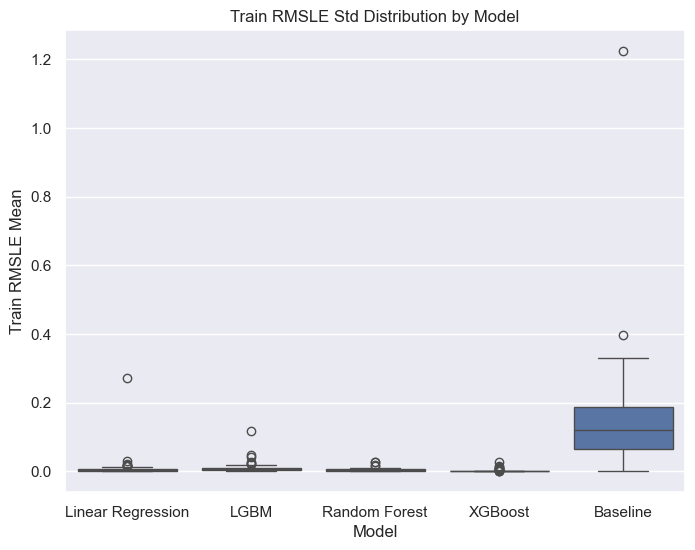

Linear Regression Std: 0.0080
LGBM Std: 0.0087
Random Forest Std: 0.0039
XGBoost Std: 0.0013
Baseline Std: 0.1412


In [56]:
# Train set std

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_train_std = df_full_metrics_linear_regression['train_rmsle_std'].mean()
lgbm_train_std = df_full_metrics_lgbm['train_rmsle_std'].mean()
random_forest_train_std = df_full_metrics_random_forest['train_rmsle_std'].mean()
xgboost_train_std = df_full_metrics_xgboost['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline['train_rmsle_std'].mean()

print(f"Linear Regression Std: {linear_regression_train_std:.4f}")
print(f"LGBM Std: {lgbm_train_std:.4f}")
print(f"Random Forest Std: {random_forest_train_std:.4f}")
print(f"XGBoost Std: {xgboost_train_std:.4f}")
print(f"Baseline Std: {baseline_train_std:.4f}")

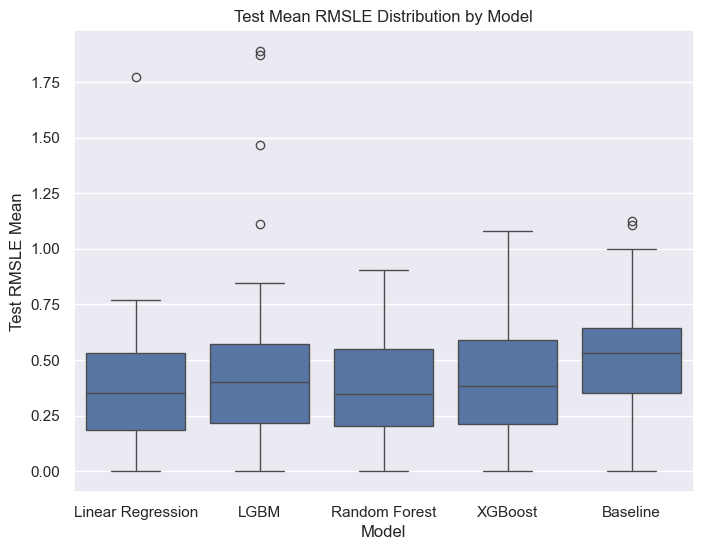

Linear Regression Mean: 0.3744
LGBM Mean: 0.4375
Random Forest Mean: 0.3778
XGBoost Mean: 0.4072
Baseline Mean: 0.5124


In [57]:
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

linear_regression_test_mean = df_full_metrics_linear_regression['test_rmsle_mean'].mean()
lgbm_test_mean = df_full_metrics_lgbm['test_rmsle_mean'].mean()
random_forest_test_mean = df_full_metrics_random_forest['test_rmsle_mean'].mean()
xgboost_test_mean = df_full_metrics_xgboost['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline['test_rmsle_mean'].mean()

print(f"Linear Regression Mean: {linear_regression_test_mean:.4f}")
print(f"LGBM Mean: {lgbm_test_mean:.4f}")
print(f"Random Forest Mean: {random_forest_test_mean:.4f}")
print(f"XGBoost Mean: {xgboost_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

In [82]:
display(df_full_metrics_random_forest[df_full_metrics_random_forest['train_rmsle_mean'] < df_full_metrics_random_forest['test_rmsle_mean']].sort_values(by='test_rmsle_mean', ascending=False))

,Unnamed: 0,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds,Model
47,47,31,LAWN AND GARDEN,0.656153,0.007604,0.646218,0.664684,0.904045,0.211886,0.652430,1.170782,7.630000e+02,146,lumpy,3,Random Forest
78,78,47,SCHOOL AND OFFICE SUPPLIES,0.287544,0.007296,0.278237,0.296055,0.872627,0.204757,0.595439,1.083772,9.710000e+03,203,lumpy,3,Random Forest
36,36,25,FROZEN FOODS,0.250344,0.006886,0.244769,0.260047,0.826424,0.506456,0.419054,1.540289,3.756097e+04,213,erratic,3,Random Forest
75,75,47,HARDWARE,0.302908,0.004470,0.298483,0.309029,0.799078,0.074341,0.738646,0.903798,5.900000e+02,188,intermittent,3,Random Forest
26,26,17,LINGERIE,0.355261,0.008693,0.346561,0.367134,0.790832,0.189729,0.539671,0.998168,1.317000e+03,205,erratic,3,Random Forest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,71,44,GROCERY I,0.063738,0.001428,0.061719,0.064754,0.124591,0.048853,0.065598,0.185228,2.294273e+06,213,smooth,3,Random Forest
3,3,3,BREAD/BAKERY,0.055612,0.001405,0.053624,0.056610,0.122423,0.007875,0.111299,0.128448,2.917217e+05,213,smooth,3,Random Forest
83,83,51,PRODUCE,0.044163,0.000414,0.043591,0.044557,0.115022,0.009892,0.103808,0.127873,1.211454e+06,213,erratic,3,Random Forest
88,88,54,PRODUCE,0.050145,0.000580,0.049545,0.050929,0.106848,0.011718,0.090277,0.115252,1.427698e+05,213,smooth,3,Random Forest


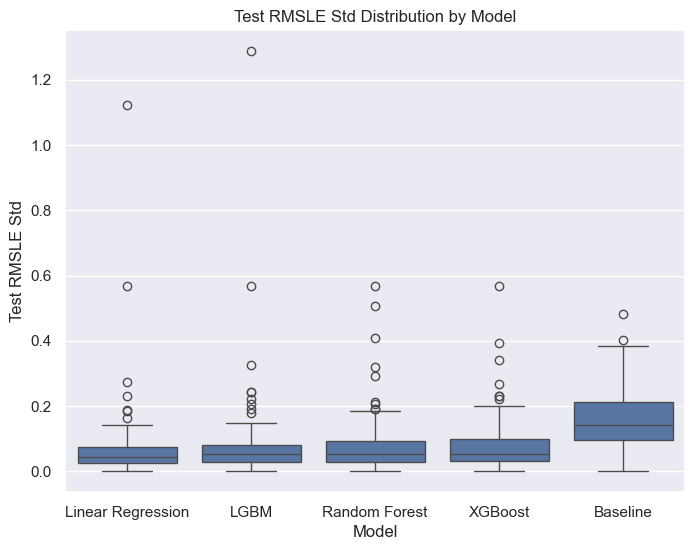

Linear Regression Std: 0.0744
LGBM Std: 0.0852
Random Forest Std: 0.0836
XGBoost Std: 0.0810
Baseline Std: 0.1592


In [58]:
# Test set std
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

linear_regression_test_std = df_full_metrics_linear_regression['test_rmsle_std'].mean()
lgbm_test_std = df_full_metrics_lgbm['test_rmsle_std'].mean()
random_forest_test_std = df_full_metrics_random_forest['test_rmsle_std'].mean()
xgboost_test_std = df_full_metrics_xgboost['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline['test_rmsle_std'].mean()

print(f"Linear Regression Std: {linear_regression_test_std:.4f}")
print(f"LGBM Std: {lgbm_test_std:.4f}")
print(f"Random Forest Std: {random_forest_test_std:.4f}")
print(f"XGBoost Std: {xgboost_test_std:.4f}")
print(f"Baseline Std: {baseline_test_std:.4f}")

## 5. 2. By Demand Type

### 5. 2. 1. Smooth

In [59]:
df_full_metrics_linear_regression_smooth = df_full_metrics_linear_regression[df_full_metrics_linear_regression['demand_type'] == 'smooth']
df_full_metrics_lgbm_smooth = df_full_metrics_lgbm[df_full_metrics_lgbm['demand_type'] == 'smooth']
df_full_metrics_random_forest_smooth = df_full_metrics_random_forest[df_full_metrics_random_forest['demand_type'] == 'smooth']
df_full_metrics_xgboost_smooth = df_full_metrics_xgboost[df_full_metrics_xgboost['demand_type'] == 'smooth']
df_full_metrics_baseline_smooth = df_full_metrics_baseline[df_full_metrics_baseline['demand_type'] == 'smooth']

df_metrics_smooth = df_metrics[df_metrics['demand_type'] == 'smooth']

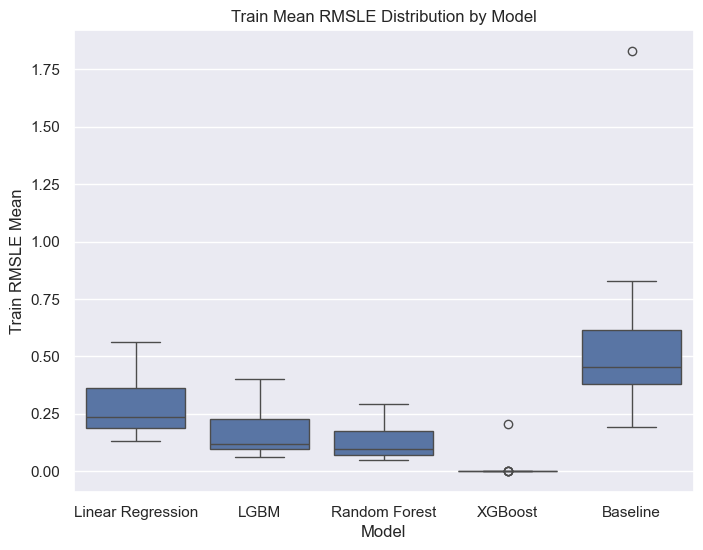

Linear Regression Mean (Smooth): 0.2848
LGBM Mean (Smooth): 0.1666
Random Forest Mean (Smooth): 0.1284
XGBoost Mean (Smooth): 0.0045
Baseline Mean (Smooth): 0.5079


In [60]:
# Train set mean

sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

linear_regression_train_mean_smooth = df_full_metrics_linear_regression_smooth['train_rmsle_mean'].mean()
lgbm_train_mean_smooth = df_full_metrics_lgbm_smooth['train_rmsle_mean'].mean()
random_forest_train_mean_smooth = df_full_metrics_random_forest_smooth['train_rmsle_mean'].mean()
xgboost_train_mean_smooth = df_full_metrics_xgboost_smooth['train_rmsle_mean'].mean()
baseline_train_mean_smooth = df_full_metrics_baseline_smooth['train_rmsle_mean'].mean()

print(f"Linear Regression Mean (Smooth): {linear_regression_train_mean_smooth:.4f}")
print(f"LGBM Mean (Smooth): {lgbm_train_mean_smooth:.4f}")
print(f"Random Forest Mean (Smooth): {random_forest_train_mean_smooth:.4f}")
print(f"XGBoost Mean (Smooth): {xgboost_train_mean_smooth:.4f}")
print(f"Baseline Mean (Smooth): {baseline_train_mean_smooth:.4f}")

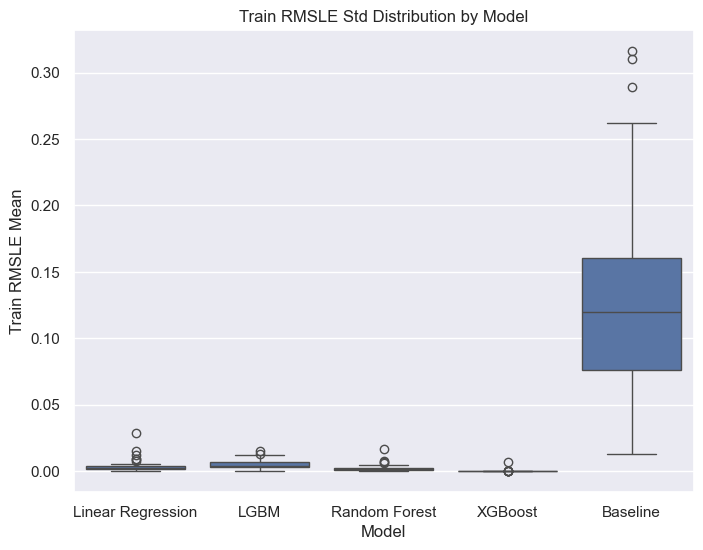

Linear Regression Std (Smooth): 0.0039
LGBM Std (Smooth): 0.0052
Random Forest Std (Smooth): 0.0023
XGBoost Std (Smooth): 0.0002
Baseline Std (Smooth): 0.1312


In [61]:
# Train set std
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_train_std_smooth = df_full_metrics_linear_regression_smooth['train_rmsle_std'].mean()
lgbm_train_std_smooth = df_full_metrics_lgbm_smooth['train_rmsle_std'].mean()
random_forest_train_std_smooth = df_full_metrics_random_forest_smooth['train_rmsle_std'].mean()
xgboost_train_std_smooth = df_full_metrics_xgboost_smooth['train_rmsle_std'].mean()
baseline_train_std_smooth = df_full_metrics_baseline_smooth['train_rmsle_std'].mean()

print(f"Linear Regression Std (Smooth): {linear_regression_train_std_smooth:.4f}")
print(f"LGBM Std (Smooth): {lgbm_train_std_smooth:.4f}")
print(f"Random Forest Std (Smooth): {random_forest_train_std_smooth:.4f}")
print(f"XGBoost Std (Smooth): {xgboost_train_std_smooth:.4f}")
print(f"Baseline Std (Smooth): {baseline_train_std_smooth:.4f}")

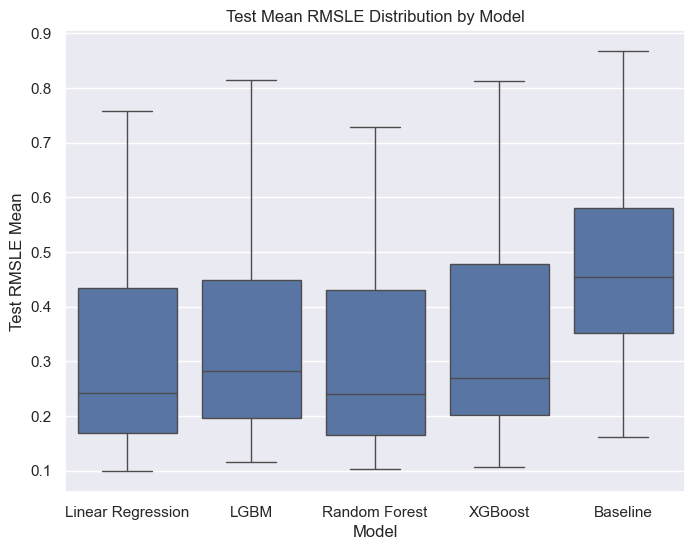

Linear Regression Mean (Smooth): 0.3021
LGBM Mean (Smooth): 0.3348
Random Forest Mean (Smooth): 0.3089
XGBoost Mean (Smooth): 0.3409
Baseline Mean (Smooth): 0.4658


In [62]:
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

linear_regression_test_mean_smooth = df_full_metrics_linear_regression_smooth['test_rmsle_mean'].mean()
lgbm_test_mean_smooth = df_full_metrics_lgbm_smooth['test_rmsle_mean'].mean()
random_forest_test_mean_smooth = df_full_metrics_random_forest_smooth['test_rmsle_mean'].mean()
xgboost_test_mean_smooth = df_full_metrics_xgboost_smooth['test_rmsle_mean'].mean()
baseline_test_mean_smooth = df_full_metrics_baseline_smooth['test_rmsle_mean'].mean()

print(f"Linear Regression Mean (Smooth): {linear_regression_test_mean_smooth:.4f}")
print(f"LGBM Mean (Smooth): {lgbm_test_mean_smooth:.4f}")
print(f"Random Forest Mean (Smooth): {random_forest_test_mean_smooth:.4f}")
print(f"XGBoost Mean (Smooth): {xgboost_test_mean_smooth:.4f}")
print(f"Baseline Mean (Smooth): {baseline_test_mean_smooth:.4f}")


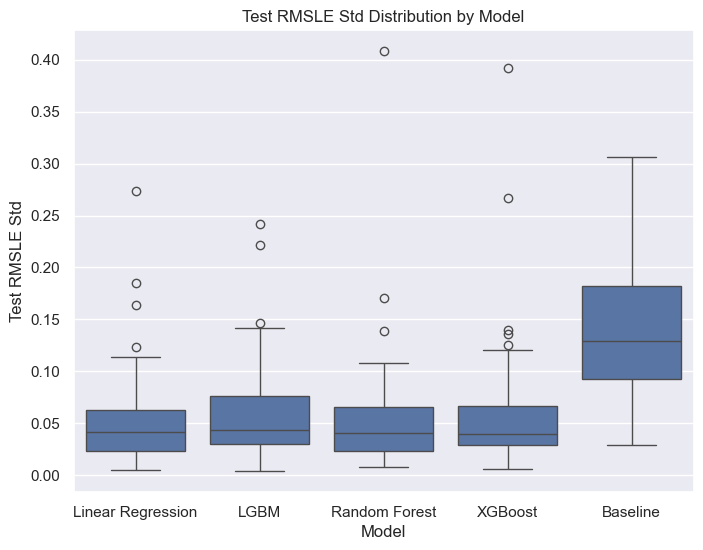

Linear Regression Std (Smooth): 0.0542
LGBM Std (Smooth): 0.0580
Random Forest Std (Smooth): 0.0556
XGBoost Std (Smooth): 0.0630


In [63]:
# Test set std
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

linear_regression_test_std_smooth = df_full_metrics_linear_regression_smooth['test_rmsle_std'].mean()
lgbm_test_std_smooth = df_full_metrics_lgbm_smooth['test_rmsle_std'].mean()
random_forest_test_std_smooth = df_full_metrics_random_forest_smooth['test_rmsle_std'].mean()
xgboost_test_std_smooth = df_full_metrics_xgboost_smooth['test_rmsle_std'].mean()

print(f"Linear Regression Std (Smooth): {linear_regression_test_std_smooth:.4f}")
print(f"LGBM Std (Smooth): {lgbm_test_std_smooth:.4f}")
print(f"Random Forest Std (Smooth): {random_forest_test_std_smooth:.4f}")
print(f"XGBoost Std (Smooth): {xgboost_test_std_smooth:.4f}")

### 5. 2. 2. Intermittent

In [64]:
df_full_metrics_linear_regression_intermittent = df_full_metrics_linear_regression[df_full_metrics_linear_regression['demand_type'] == 'intermittent']
df_full_metrics_lgbm_intermittent = df_full_metrics_lgbm[df_full_metrics_lgbm['demand_type'] == 'intermittent']
df_full_metrics_random_forest_intermittent = df_full_metrics_random_forest[df_full_metrics_random_forest['demand_type'] == 'intermittent']
df_full_metrics_xgboost_intermittent = df_full_metrics_xgboost[df_full_metrics_xgboost['demand_type'] == 'intermittent']

df_metrics_intermittent = df_metrics[df_metrics['demand_type'] == 'intermittent']

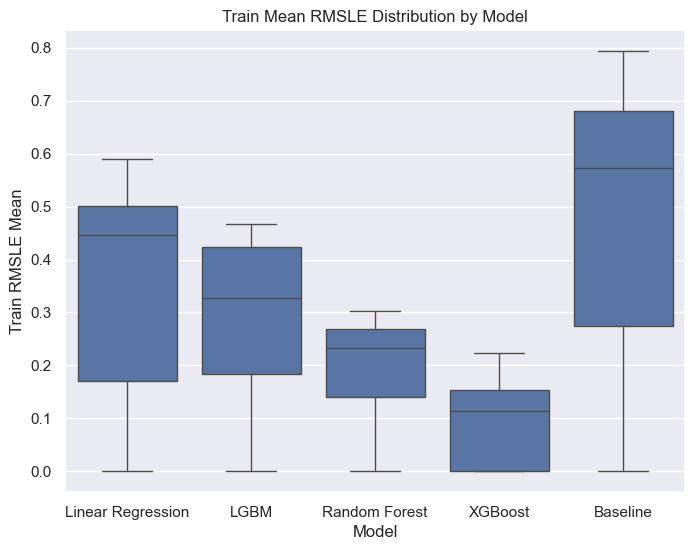

Linear Regression Mean (intermittent): 0.3330
LGBM Mean (intermittent): 0.2789
Random Forest Mean (intermittent): 0.1898
XGBoost Mean (intermittent): 0.0899


In [65]:
# Train set mean

sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

linear_regression_train_mean_intermittent = df_full_metrics_linear_regression_intermittent['train_rmsle_mean'].mean()
lgbm_train_mean_intermittent = df_full_metrics_lgbm_intermittent['train_rmsle_mean'].mean()
random_forest_train_mean_intermittent = df_full_metrics_random_forest_intermittent['train_rmsle_mean'].mean()
xgboost_train_mean_intermittent = df_full_metrics_xgboost_intermittent['train_rmsle_mean'].mean()

print(f"Linear Regression Mean (intermittent): {linear_regression_train_mean_intermittent:.4f}")
print(f"LGBM Mean (intermittent): {lgbm_train_mean_intermittent:.4f}")
print(f"Random Forest Mean (intermittent): {random_forest_train_mean_intermittent:.4f}")
print(f"XGBoost Mean (intermittent): {xgboost_train_mean_intermittent:.4f}")

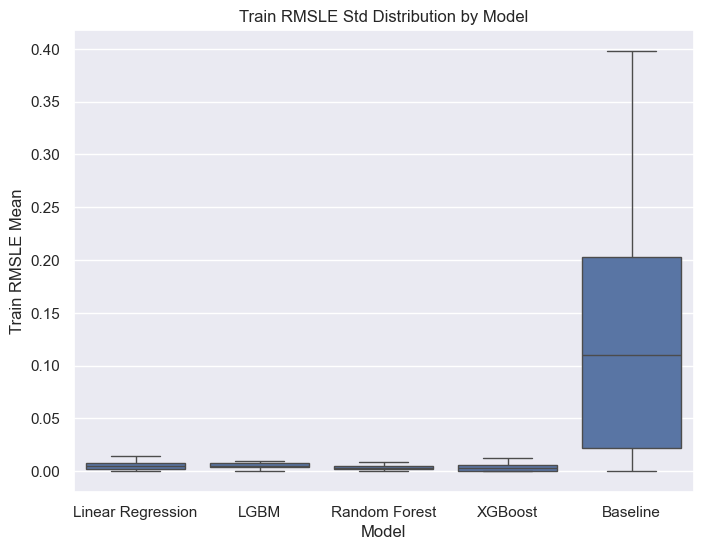

Linear Regression Std (intermittent): 0.0052
LGBM Std (intermittent): 0.0053
Random Forest Std (intermittent): 0.0035
XGBoost Std (intermittent): 0.0039


In [66]:
# Train set std
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_train_std_intermittent = df_full_metrics_linear_regression_intermittent['train_rmsle_std'].mean()
lgbm_train_std_intermittent = df_full_metrics_lgbm_intermittent['train_rmsle_std'].mean()
random_forest_train_std_intermittent = df_full_metrics_random_forest_intermittent['train_rmsle_std'].mean()
xgboost_train_std_intermittent = df_full_metrics_xgboost_intermittent['train_rmsle_std'].mean()

print(f"Linear Regression Std (intermittent): {linear_regression_train_std_intermittent:.4f}")
print(f"LGBM Std (intermittent): {lgbm_train_std_intermittent:.4f}")
print(f"Random Forest Std (intermittent): {random_forest_train_std_intermittent:.4f}")
print(f"XGBoost Std (intermittent): {xgboost_train_std_intermittent:.4f}")

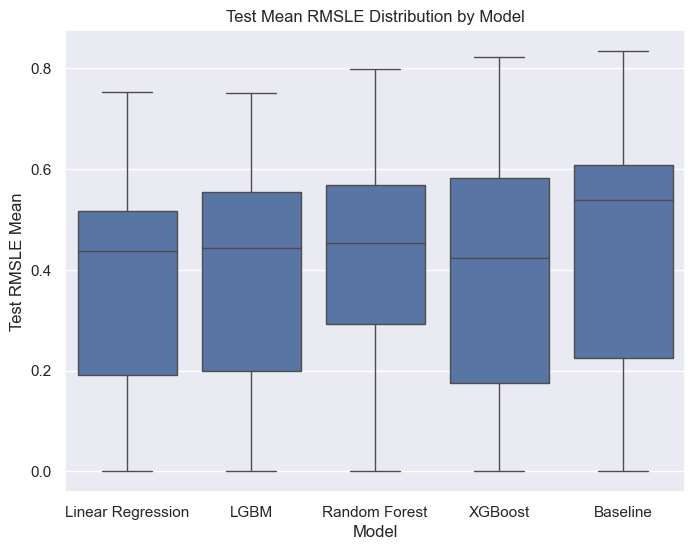

Linear Regression Mean (intermittent): 0.3614
LGBM Mean (intermittent): 0.3715
Random Forest Mean (intermittent): 0.3914
XGBoost Mean (intermittent): 0.3764


In [67]:
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

linear_regression_test_mean_intermittent = df_full_metrics_linear_regression_intermittent['test_rmsle_mean'].mean()
lgbm_test_mean_intermittent = df_full_metrics_lgbm_intermittent['test_rmsle_mean'].mean()
random_forest_test_mean_intermittent = df_full_metrics_random_forest_intermittent['test_rmsle_mean'].mean()
xgboost_test_mean_intermittent = df_full_metrics_xgboost_intermittent['test_rmsle_mean'].mean()

print(f"Linear Regression Mean (intermittent): {linear_regression_test_mean_intermittent:.4f}")
print(f"LGBM Mean (intermittent): {lgbm_test_mean_intermittent:.4f}")
print(f"Random Forest Mean (intermittent): {random_forest_test_mean_intermittent:.4f}")
print(f"XGBoost Mean (intermittent): {xgboost_test_mean_intermittent:.4f}")


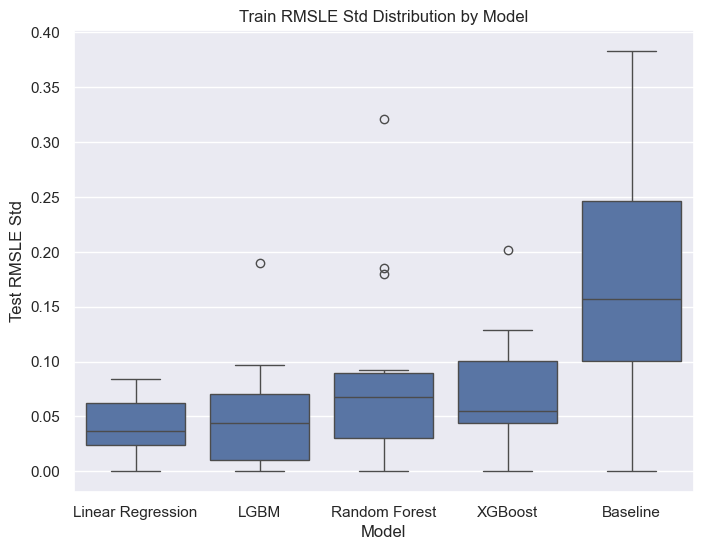

Linear Regression Std (intermittent): 0.0404
LGBM Std (intermittent): 0.0513
Random Forest Std (intermittent): 0.0842
XGBoost Std (intermittent): 0.0695


In [68]:
# Test set std
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_test_std_intermittent = df_full_metrics_linear_regression_intermittent['test_rmsle_std'].mean()
lgbm_test_std_intermittent = df_full_metrics_lgbm_intermittent['test_rmsle_std'].mean()
random_forest_test_std_intermittent = df_full_metrics_random_forest_intermittent['test_rmsle_std'].mean()
xgboost_test_std_intermittent = df_full_metrics_xgboost_intermittent['test_rmsle_std'].mean()

print(f"Linear Regression Std (intermittent): {linear_regression_test_std_intermittent:.4f}")
print(f"LGBM Std (intermittent): {lgbm_test_std_intermittent:.4f}")
print(f"Random Forest Std (intermittent): {random_forest_test_std_intermittent:.4f}")
print(f"XGBoost Std (intermittent): {xgboost_test_std_intermittent:.4f}")

### 5. 2. 3. Erratic

In [69]:
df_full_metrics_linear_regression_erratic = df_full_metrics_linear_regression[df_full_metrics_linear_regression['demand_type'] == 'erratic']
df_full_metrics_lgbm_erratic = df_full_metrics_lgbm[df_full_metrics_lgbm['demand_type'] == 'erratic']
df_full_metrics_random_forest_erratic = df_full_metrics_random_forest[df_full_metrics_random_forest['demand_type'] == 'erratic']
df_full_metrics_xgboost_erratic = df_full_metrics_xgboost[df_full_metrics_xgboost['demand_type'] == 'erratic']

df_metrics_erratic = df_metrics[df_metrics['demand_type'] == 'erratic']

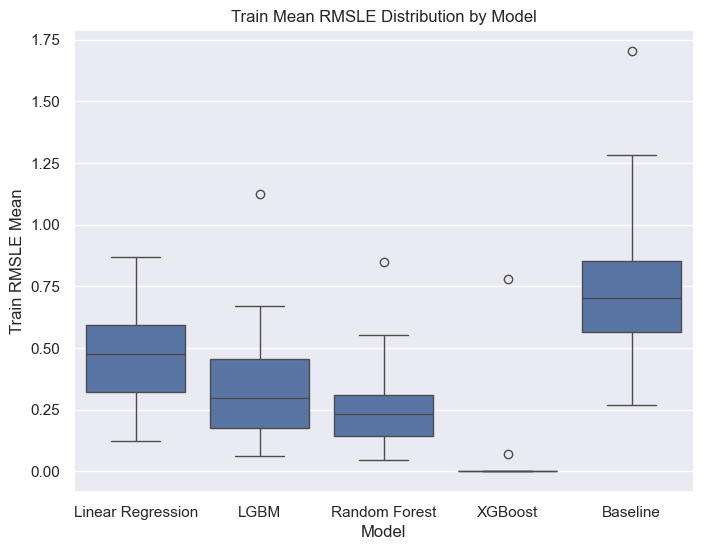

Linear Regression Mean (erratic): 0.4864
LGBM Mean (erratic): 0.3595
Random Forest Mean (erratic): 0.2625
XGBoost Mean (erratic): 0.0450


In [70]:
# Train set mean

sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

linear_regression_train_mean_erratic = df_full_metrics_linear_regression_erratic['train_rmsle_mean'].mean()
lgbm_train_mean_erratic = df_full_metrics_lgbm_erratic['train_rmsle_mean'].mean()
random_forest_train_mean_erratic = df_full_metrics_random_forest_erratic['train_rmsle_mean'].mean()
xgboost_train_mean_erratic = df_full_metrics_xgboost_erratic['train_rmsle_mean'].mean()

print(f"Linear Regression Mean (erratic): {linear_regression_train_mean_erratic:.4f}")
print(f"LGBM Mean (erratic): {lgbm_train_mean_erratic:.4f}")
print(f"Random Forest Mean (erratic): {random_forest_train_mean_erratic:.4f}")
print(f"XGBoost Mean (erratic): {xgboost_train_mean_erratic:.4f}")

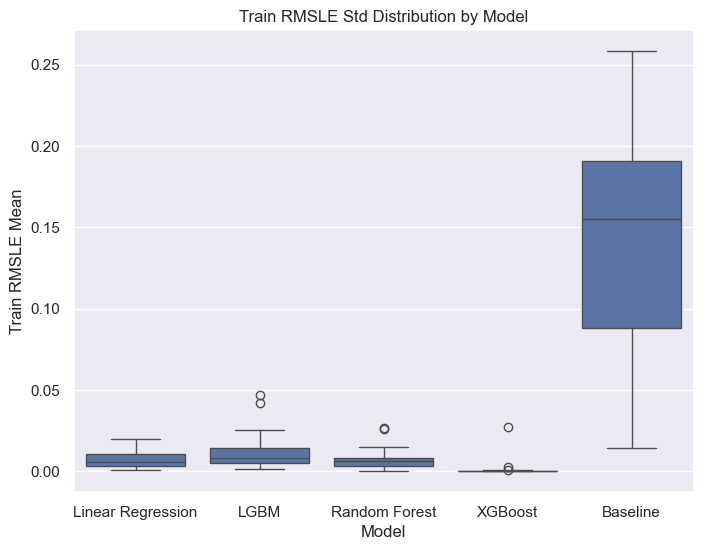

Linear Regression Std (erratic): 0.0073
LGBM Std (erratic): 0.0129
Random Forest Std (erratic): 0.0076
XGBoost Std (erratic): 0.0017


In [71]:
# Train set std
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_train_std_erratic = df_full_metrics_linear_regression_erratic['train_rmsle_std'].mean()
lgbm_train_std_erratic = df_full_metrics_lgbm_erratic['train_rmsle_std'].mean()
random_forest_train_std_erratic = df_full_metrics_random_forest_erratic['train_rmsle_std'].mean()
xgboost_train_std_erratic = df_full_metrics_xgboost_erratic['train_rmsle_std'].mean()

print(f"Linear Regression Std (erratic): {linear_regression_train_std_erratic:.4f}")
print(f"LGBM Std (erratic): {lgbm_train_std_erratic:.4f}")
print(f"Random Forest Std (erratic): {random_forest_train_std_erratic:.4f}")
print(f"XGBoost Std (erratic): {xgboost_train_std_erratic:.4f}")

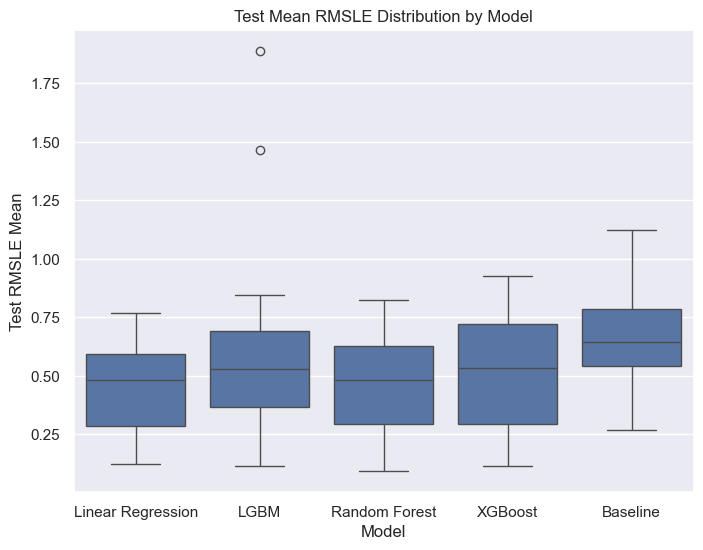

Linear Regression Mean (erratic): 0.4447
LGBM Mean (erratic): 0.5996
Random Forest Mean (erratic): 0.4576
XGBoost Mean (erratic): 0.5038


In [72]:
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

linear_regression_test_mean_erratic = df_full_metrics_linear_regression_erratic['test_rmsle_mean'].mean()
lgbm_test_mean_erratic = df_full_metrics_lgbm_erratic['test_rmsle_mean'].mean()
random_forest_test_mean_erratic = df_full_metrics_random_forest_erratic['test_rmsle_mean'].mean()
xgboost_test_mean_erratic = df_full_metrics_xgboost_erratic['test_rmsle_mean'].mean()

print(f"Linear Regression Mean (erratic): {linear_regression_test_mean_erratic:.4f}")
print(f"LGBM Mean (erratic): {lgbm_test_mean_erratic:.4f}")
print(f"Random Forest Mean (erratic): {random_forest_test_mean_erratic:.4f}")
print(f"XGBoost Mean (erratic): {xgboost_test_mean_erratic:.4f}")


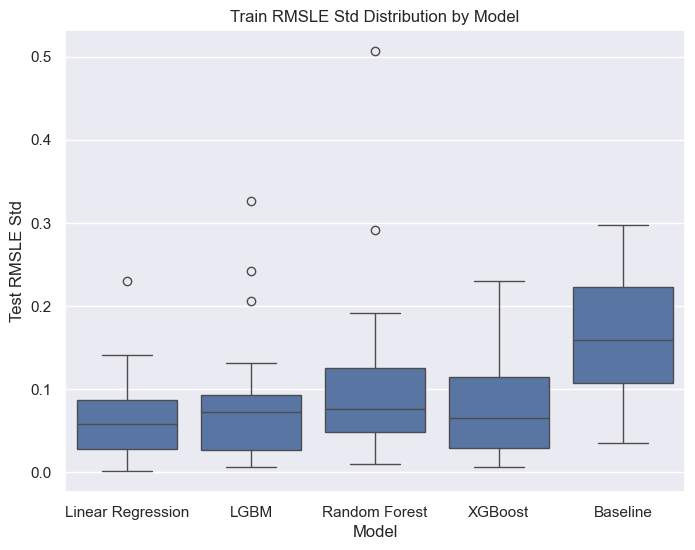

Linear Regression Std (erratic): 0.0672
LGBM Std (erratic): 0.0893
Random Forest Std (erratic): 0.1132
XGBoost Std (erratic): 0.0818


In [73]:
# Test set std
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_test_std_erratic = df_full_metrics_linear_regression_erratic['test_rmsle_std'].mean()
lgbm_test_std_erratic = df_full_metrics_lgbm_erratic['test_rmsle_std'].mean()
random_forest_test_std_erratic = df_full_metrics_random_forest_erratic['test_rmsle_std'].mean()
xgboost_test_std_erratic = df_full_metrics_xgboost_erratic['test_rmsle_std'].mean()

print(f"Linear Regression Std (erratic): {linear_regression_test_std_erratic:.4f}")
print(f"LGBM Std (erratic): {lgbm_test_std_erratic:.4f}")
print(f"Random Forest Std (erratic): {random_forest_test_std_erratic:.4f}")
print(f"XGBoost Std (erratic): {xgboost_test_std_erratic:.4f}")

### 5. 2. 4. Lumpy

In [74]:
df_full_metrics_linear_regression_lumpy = df_full_metrics_linear_regression[df_full_metrics_linear_regression['demand_type'] == 'lumpy']
df_full_metrics_lgbm_lumpy = df_full_metrics_lgbm[df_full_metrics_lgbm['demand_type'] == 'lumpy']
df_full_metrics_random_forest_lumpy = df_full_metrics_random_forest[df_full_metrics_random_forest['demand_type'] == 'lumpy']
df_full_metrics_xgboost_lumpy = df_full_metrics_xgboost[df_full_metrics_xgboost['demand_type'] == 'lumpy']

df_metrics_lumpy = df_metrics[df_metrics['demand_type'] == 'lumpy']

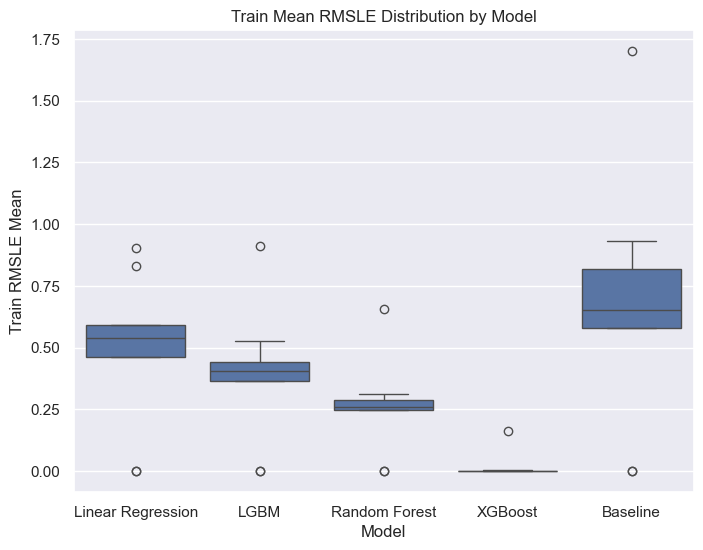

Linear Regression Mean (lumpy): 0.4887
LGBM Mean (lumpy): 0.3876
Random Forest Mean (lumpy): 0.2561
XGBoost Mean (lumpy): 0.0195


In [75]:
# Train set mean

sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

linear_regression_train_mean_lumpy = df_full_metrics_linear_regression_lumpy['train_rmsle_mean'].mean()
lgbm_train_mean_lumpy = df_full_metrics_lgbm_lumpy['train_rmsle_mean'].mean()
random_forest_train_mean_lumpy = df_full_metrics_random_forest_lumpy['train_rmsle_mean'].mean()
xgboost_train_mean_lumpy = df_full_metrics_xgboost_lumpy['train_rmsle_mean'].mean()

print(f"Linear Regression Mean (lumpy): {linear_regression_train_mean_lumpy:.4f}")
print(f"LGBM Mean (lumpy): {lgbm_train_mean_lumpy:.4f}")
print(f"Random Forest Mean (lumpy): {random_forest_train_mean_lumpy:.4f}")
print(f"XGBoost Mean (lumpy): {xgboost_train_mean_lumpy:.4f}")

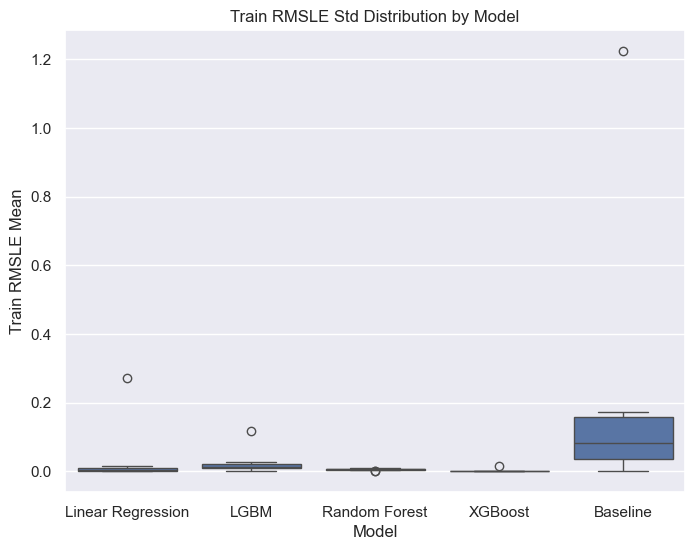

Linear Regression Std (lumpy): 0.0349
LGBM Std (lumpy): 0.0236
Random Forest Std (lumpy): 0.0054
XGBoost Std (lumpy): 0.0022


In [76]:
# Train set std
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_train_std_lumpy = df_full_metrics_linear_regression_lumpy['train_rmsle_std'].mean()
lgbm_train_std_lumpy = df_full_metrics_lgbm_lumpy['train_rmsle_std'].mean()
random_forest_train_std_lumpy = df_full_metrics_random_forest_lumpy['train_rmsle_std'].mean()
xgboost_train_std_lumpy = df_full_metrics_xgboost_lumpy['train_rmsle_std'].mean()

print(f"Linear Regression Std (lumpy): {linear_regression_train_std_lumpy:.4f}")
print(f"LGBM Std (lumpy): {lgbm_train_std_lumpy:.4f}")
print(f"Random Forest Std (lumpy): {random_forest_train_std_lumpy:.4f}")
print(f"XGBoost Std (lumpy): {xgboost_train_std_lumpy:.4f}")

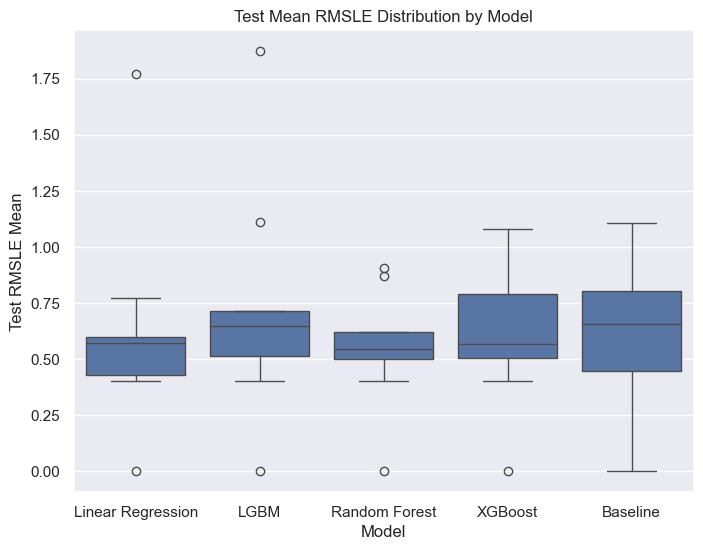

Linear Regression Mean (lumpy): 0.6241
LGBM Mean (lumpy): 0.7342
Random Forest Mean (lumpy): 0.5479
XGBoost Mean (lumpy): 0.5975


In [77]:
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

linear_regression_test_mean_lumpy = df_full_metrics_linear_regression_lumpy['test_rmsle_mean'].mean()
lgbm_test_mean_lumpy = df_full_metrics_lgbm_lumpy['test_rmsle_mean'].mean()
random_forest_test_mean_lumpy = df_full_metrics_random_forest_lumpy['test_rmsle_mean'].mean()
xgboost_test_mean_lumpy = df_full_metrics_xgboost_lumpy['test_rmsle_mean'].mean()

print(f"Linear Regression Mean (lumpy): {linear_regression_test_mean_lumpy:.4f}")
print(f"LGBM Mean (lumpy): {lgbm_test_mean_lumpy:.4f}")
print(f"Random Forest Mean (lumpy): {random_forest_test_mean_lumpy:.4f}")
print(f"XGBoost Mean (lumpy): {xgboost_test_mean_lumpy:.4f}")


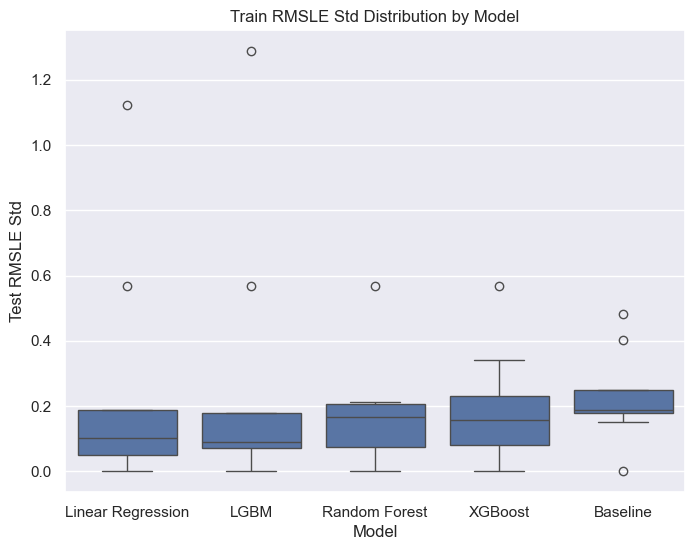

Linear Regression Std (lumpy): 0.2483
LGBM Std (lumpy): 0.2714
Random Forest Std (lumpy): 0.1668
XGBoost Std (lumpy): 0.1914


In [78]:
# Test set std
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

linear_regression_test_std_lumpy = df_full_metrics_linear_regression_lumpy['test_rmsle_std'].mean()
lgbm_test_std_lumpy = df_full_metrics_lgbm_lumpy['test_rmsle_std'].mean()
random_forest_test_std_lumpy = df_full_metrics_random_forest_lumpy['test_rmsle_std'].mean()
xgboost_test_std_lumpy = df_full_metrics_xgboost_lumpy['test_rmsle_std'].mean()

print(f"Linear Regression Std (lumpy): {linear_regression_test_std_lumpy:.4f}")
print(f"LGBM Std (lumpy): {lgbm_test_std_lumpy:.4f}")
print(f"Random Forest Std (lumpy): {random_forest_test_std_lumpy:.4f}")
print(f"XGBoost Std (lumpy): {xgboost_test_std_lumpy:.4f}")

# 6. Final Conclusions

The analyzed time series exhibited intermittent behavior, high temporal sparsity, and possible regime changes throughout the historical data. In this context, more complex models, such as tree-based boosting algorithms, showed a tendency to overfit and struggled to properly calibrate the magnitude of demand peaks and troughs. In contrast, more parsimonious statistical models demonstrated better generalization capability and greater predictive stability.

The model with the best overall performance, considering all cases, was Prophet.